# Neuro-Pulse: rPPG-Based Deepfake Detection — ML Training

## Traditional Machine Learning Models

This notebook trains **7 ML classifiers** + a **Voting Ensemble** on the 35-dimensional rPPG feature vectors
extracted from real and deepfake videos.

**Models:**
1. Random Forest
2. XGBoost
3. LightGBM
4. Support Vector Machine (RBF)
5. Gradient Boosting
6. Extra Trees
7. Logistic Regression
8. Soft Voting Ensemble (top-3)

**Pipeline:** Feature extraction → StandardScaler → 3-Fold CV → Pre-Tuned Models → Evaluation

**Dataset:** `/kaggle/input/datasets/likhithvasireddy/deepfake-video-dataset-dip/.../face_dataset_dip/{real_videos, deepfake_videos}`

**References:**
- FakeCatcher (Ciftci et al., TPAMI 2020) — SNR + PSD + MAD + SD + PCC features
- DeepFakesON-Phys (Hernandez-Ortega et al., 2020)
- pyVHR (Boccignone et al., 2022)

## 1. Setup & Imports

In [1]:
# ─── Install mediapipe (pin numpy-compatible version) ────────────
import subprocess, sys

# Force numpy 1.26.4 compatibility
subprocess.run([
    sys.executable, "-m", "pip", "install",
    "mediapipe==0.10.21",
    "--no-deps",          # ← key flag: skips dependency resolution entirely
    "-q"
], check=True)

print("mediapipe installed.")

mediapipe installed.


In [2]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from time import time
import mediapipe as mp_module          # ← add this line
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier, VotingClassifier
)
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import lightgbm as lgb
import joblib
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
print(f"NumPy      : {np.__version__}")
print(f"MediaPipe  : {mp_module.__version__}")
print(f"XGBoost    : {xgb.__version__}")
print(f"LightGBM   : {lgb.__version__}")
print("Setup complete.")

2026-03-16 08:01:21.508093: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773648081.530359     166 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773648081.536877     166 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773648081.553569     166 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773648081.553600     166 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773648081.553603     166 computation_placer.cc:177] computation placer alr

NumPy      : 1.26.4
MediaPipe  : 0.10.21
XGBoost    : 3.1.3
LightGBM   : 4.6.0
Setup complete.


## 2. Feature Extraction from Dataset

This cell runs the full video processing pipeline on the Kaggle dataset.
It extracts 35 rPPG features per video and saves them.

**Run this cell ONCE** — it takes time. After that, load from saved files.

In [3]:
# ─── Configuration ───────────────────────────────────────────────
# Kaggle dataset path
DATASET_ROOT = "/kaggle/input/datasets/likhithvasireddy/deepfake-video-dataset-dip/content/drive/MyDrive/face_dataset_dip"
REAL_DIR = os.path.join(DATASET_ROOT, "real_videos")
FAKE_DIR = os.path.join(DATASET_ROOT, "deepfake_videos")
OUTPUT_DIR = "/kaggle/working/features"
RPPG_METHOD = "GREEN"  # GREEN, CHROM, or POS
MAX_FRAMES_PER_VIDEO = 300  # 10 seconds at 30fps — enough for rPPG, safe on Kaggle

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Verify dataset exists
print(f"Dataset root exists: {os.path.exists(DATASET_ROOT)}")
print(f"Real videos dir exists: {os.path.exists(REAL_DIR)}")
print(f"Fake videos dir exists: {os.path.exists(FAKE_DIR)}")

# If the above shows False, try discovering the actual structure:
if not os.path.exists(REAL_DIR):
    print("\n[WARN] Expected path not found. Scanning dataset root...")
    base = "/kaggle/input"
    for d in os.listdir(base):
        full = os.path.join(base, d)
        if os.path.isdir(full):
            print(f"  /kaggle/input/{d}/")
            for sub in os.listdir(full)[:10]:
                print(f"    {sub}/")
    print("\n[ACTION] Update DATASET_ROOT, REAL_DIR, FAKE_DIR above to match your actual paths.")
else:
    real_files = [f for f in os.listdir(REAL_DIR) if f.endswith(('.mp4', '.avi', '.mov'))]
    print(f"Real videos count: {len(real_files)}")
    fake_files = [f for f in os.listdir(FAKE_DIR) if f.endswith(('.mp4', '.avi', '.mov'))]
    print(f"Fake videos count: {len(fake_files)}")

Dataset root exists: True
Real videos dir exists: True
Fake videos dir exists: True
Real videos count: 200
Fake videos count: 200


In [5]:
# ─── Run Feature Extraction Pipeline ─────────────────────────────
# This processes ALL videos and saves features. Run ONCE.

import glob
import cv2
import mediapipe as mp_module
from scipy.signal import butter, filtfilt, welch, find_peaks, coherence, csd
from scipy.stats import pearsonr, kurtosis, skew
from tqdm import tqdm

# ──────────────────────────────────────────────────────────────────
# Inline all necessary functions so this notebook is self-contained
# ──────────────────────────────────────────────────────────────────

# ROI landmark indices (MediaPipe Face Mesh)
ROI_FOREHEAD = [10, 338, 297, 332, 284, 251, 389, 356, 454, 323, 361,
                288, 397, 365, 379, 378, 400, 377, 152, 148, 176, 149,
                150, 136, 172, 58, 132, 93, 234, 127, 162, 21, 54, 103, 67, 109]
ROI_LEFT_CHEEK = [187, 123, 116, 117, 118, 119, 120, 121, 128, 245, 193, 55, 65, 52, 53]
ROI_RIGHT_CHEEK = [411, 352, 345, 346, 347, 348, 349, 350, 357, 465, 417, 285, 295, 282, 283]

BANDPASS_LOW = 0.7
BANDPASS_HIGH = 3.5
BANDPASS_ORDER = 4

FEATURE_NAMES = [
    "fh_snr", "fh_spectral_purity", "fh_peak_prominence",
    "fh_dominant_freq", "fh_harmonic_ratio", "fh_spectral_entropy",
    "fh_spectral_centroid",
    "fh_mad", "fh_std", "fh_zcr", "fh_kurtosis", "fh_skewness",
    "lc_snr", "lc_spectral_purity", "lc_peak_prominence",
    "lc_dominant_freq", "lc_harmonic_ratio", "lc_spectral_entropy",
    "lc_spectral_centroid",
    "lc_mad", "lc_std", "lc_zcr", "lc_kurtosis", "lc_skewness",
    "corr_fh_lc", "corr_fh_rc", "corr_lc_rc",
    "coherence_fh_lc", "coherence_fh_rc", "coherence_lc_rc",
    "phase_diff_fh_lc", "phase_diff_fh_rc",
    "bpm_estimate", "signal_stationarity", "bpm_consistency",
]


def bandpass_filter(signal, fs, lowcut=0.7, highcut=3.5, order=4):
    nyq = 0.5 * fs
    low = max(lowcut / nyq, 0.001)
    high = min(highcut / nyq, 0.999)
    if low >= high:
        return signal
    b, a = butter(order, [low, high], btype='band')
    if len(signal) < 3 * max(len(a), len(b)):
        return signal
    return filtfilt(b, a, signal)


def detrend_signal(signal, lam=300):
    n = len(signal)
    if n < 5:
        return signal
    I = np.eye(n)
    D2 = np.zeros((n - 2, n))
    for i in range(n - 2):
        D2[i, i] = 1; D2[i, i+1] = -2; D2[i, i+2] = 1
    return signal - np.linalg.solve(I + lam**2 * D2.T @ D2, signal)


def extract_green(rgb_mean):
    return rgb_mean[:, 1].copy()


def extract_chrom(rgb_mean, fs=30):
    r = rgb_mean[:, 0] / (np.mean(rgb_mean[:, 0]) + 1e-8)
    g = rgb_mean[:, 1] / (np.mean(rgb_mean[:, 1]) + 1e-8)
    b = rgb_mean[:, 2] / (np.mean(rgb_mean[:, 2]) + 1e-8)
    xs = 3*r - 2*g
    ys = 1.5*r + g - 1.5*b
    win = max(int(1.6*fs), 2)
    bvp = np.zeros(len(r))
    for i in range(len(r)):
        s, e = max(0, i-win//2), min(len(r), i+win//2)
        alpha = np.std(xs[s:e]) / (np.std(ys[s:e]) + 1e-8)
        bvp[i] = xs[i] - alpha * ys[i]
    return bvp


def extract_pos(rgb_mean, fs=30):
    n = rgb_mean.shape[0]
    win = max(int(1.6*fs), 2)
    bvp = np.zeros(n)
    for i in range(n):
        s = max(0, i-win+1)
        if i-s < 2: continue
        w = rgb_mean[s:i+1]
        m = np.mean(w, axis=0); m[m<1e-8] = 1e-8
        cn = w / m
        s1 = cn[:,1]-cn[:,2]; s2 = cn[:,1]+cn[:,2]-2*cn[:,0]
        alpha = np.std(s1)/(np.std(s2)+1e-8)
        bvp[i] = (s1+alpha*s2)[-1]
    return bvp


RPPG_METHODS = {"GREEN": extract_green, "CHROM": extract_chrom, "POS": extract_pos}


def compute_welch_psd(bvp, fs, nperseg=256, noverlap=128, nfft=1024):
    nperseg = min(nperseg, len(bvp))
    noverlap = min(noverlap, nperseg - 1)
    return welch(bvp, fs=fs, nperseg=nperseg, noverlap=noverlap, nfft=nfft)


def get_roi_mean_rgb(frame, landmarks, roi_indices, h, w):
    pts = []
    for idx in roi_indices:
        lm = landmarks.landmark[idx]
        x = max(0, min(int(lm.x * w), w-1))
        y = max(0, min(int(lm.y * h), h-1))
        pts.append((x, y))
    if len(pts) < 3: return None
    pts = np.array(pts, dtype=np.int32)
    x0, y0 = np.min(pts, axis=0); x1, y1 = np.max(pts, axis=0)
    x0, y0, x1, y1 = max(0,x0), max(0,y0), min(w,x1), min(h,y1)
    if x1<=x0 or y1<=y0: return None
    roi = frame[y0:y1, x0:x1]
    if roi.size==0: return None
    return np.mean(roi.reshape(-1,3), axis=0)[::-1].astype(np.float64)


def _extract_35_features(bvp_fh, bvp_lc, bvp_rc, fs):
    """Extract the full 35-feature vector."""
    fl = BANDPASS_LOW
    fh = BANDPASS_HIGH
    
    def _roi_features(bvp):
        if len(bvp) < 10:
            return [0.0]*12
        freqs, psd = compute_welch_psd(bvp, fs)
        mask = (freqs >= fl) & (freqs <= fh)
        if not np.any(mask):
            return [0.0]*12
        mp_ = psd[mask]; mf = freqs[mask]
        pi = np.argmax(mp_); pf = mf[pi]
        # SNR
        sm = np.abs(mf-pf)<=0.2; nm = ~sm
        sp_ = np.sum(mp_[sm]); np_ = np.sum(mp_[nm])
        snr = 10*np.log10(sp_/(np_+1e-10)) if np_>1e-10 else 40.0
        # Spectral purity
        spur = sp_/(np.sum(mp_)+1e-10)
        # Peak prominence
        peaks, props = find_peaks(mp_, prominence=0)
        pp = float(np.max(props['prominences'])) if len(peaks)>0 else 0.0
        # Harmonic ratio
        hf = 2*pf
        hm = (freqs>=hf-0.15)&(freqs<=hf+0.15)
        hr = float(np.max(psd[hm])/mp_[pi]) if np.any(hm) and mp_[pi]>1e-10 else 0.0
        # Spectral entropy
        pn = mp_/(np.sum(mp_)+1e-10); pn = pn[pn>0]
        se = float(-np.sum(pn*np.log2(pn+1e-10)))
        # Spectral centroid
        sc = float(np.sum(mf*mp_)/(np.sum(mp_)+1e-10))
        # Temporal
        mad = float(np.mean(np.abs(bvp-np.mean(bvp))))
        std = float(np.std(bvp))
        zcr = float(np.sum(np.abs(np.diff(np.sign(bvp)))>0)/(len(bvp)-1)) if len(bvp)>1 else 0.0
        kurt = float(kurtosis(bvp)) if len(bvp)>3 else 0.0
        skewn = float(skew(bvp)) if len(bvp)>3 else 0.0
        return [snr, spur, pp, float(pf), hr, se, sc, mad, std, zcr, kurt, skewn]
    
    fh_f = _roi_features(bvp_fh)
    lc_f = _roi_features(bvp_lc)
    
    # Cross-ROI
    def _corr(a, b):
        ml = min(len(a), len(b))
        if ml<3: return 0.0
        c, _ = pearsonr(a[:ml], b[:ml])
        return 0.0 if np.isnan(c) else float(c)
    
    def _coh(a, b):
        ns = min(256, min(len(a), len(b)))
        if ns<4: return 0.0
        f, c = coherence(a, b, fs=fs, nperseg=ns)
        m = (f>=fl)&(f<=fh)
        return float(np.mean(c[m])) if np.any(m) else 0.0
    
    def _phase(a, b):
        ns = min(256, min(len(a), len(b)))
        if ns<4: return 0.0
        f, pxy = csd(a, b, fs=fs, nperseg=ns)
        m = (f>=fl)&(f<=fh)
        if not np.any(m): return 0.0
        return float(np.abs(np.angle(pxy[m][np.argmax(np.abs(pxy[m]))])))
    
    c_fl = _corr(bvp_fh, bvp_lc)
    c_fr = _corr(bvp_fh, bvp_rc)
    c_lr = _corr(bvp_lc, bvp_rc)
    coh_fl = _coh(bvp_fh, bvp_lc)
    coh_fr = _coh(bvp_fh, bvp_rc)
    coh_lr = _coh(bvp_lc, bvp_rc)
    ph_fl = _phase(bvp_fh, bvp_lc)
    ph_fr = _phase(bvp_fh, bvp_rc)
    
    # BPM
    def _bpm(bvp):
        f, p = compute_welch_psd(bvp, fs)
        m = (f>=fl)&(f<=fh)
        if not np.any(m): return 0.0
        return float(f[m][np.argmax(p[m])]*60)
    
    bpm = _bpm(bvp_fh)
    bpm_lc = _bpm(bvp_lc)
    bpm_rc = _bpm(bvp_rc)
    
    # Stationarity
    segs = np.array_split(bvp_fh, 4) if len(bvp_fh)>=8 else [bvp_fh]
    vs = [np.var(s) for s in segs]
    mv = np.mean(vs)
    stat = max(0.0, 1.0 - np.std(vs)/(mv+1e-10)) if mv>1e-10 else 1.0
    
    # BPM consistency
    bpms = [bpm, bpm_lc, bpm_rc]
    bm = np.mean(bpms)
    bcon = max(0.0, min(1.0, 1.0 - np.std(bpms)/(bm+1e-8)))
    
    feat = np.array(fh_f + lc_f + [
        c_fl, c_fr, c_lr, coh_fl, coh_fr, coh_lr, ph_fl, ph_fr,
        bpm, stat, bcon
    ], dtype=np.float64)
    return np.nan_to_num(feat, nan=0.0, posinf=40.0, neginf=-40.0)


# ──────────────────────────────────────────────────────────────────
# FIX 3: Initialize FaceMesh ONCE — reused for all videos
# refine_landmarks=False saves ~30% per frame (we don't use eye/lip refinement)
# ──────────────────────────────────────────────────────────────────
_FACE_MESH = mp_module.solutions.face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    refine_landmarks=False,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5,
)


def process_video(video_path, method="GREEN", max_frames=300):
    """Extract 35 rPPG features from a single video. Uses shared FaceMesh instance."""
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return None
    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps <= 0 or fps > 120: fps = 30.0
    
    rgb_fh, rgb_lc, rgb_rc = [], [], []
    fc = 0
    while fc < max_frames:
        ret, frame = cap.read()
        if not ret: break
        fc += 1
        h, w = frame.shape[:2]
        res = _FACE_MESH.process(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        if res.multi_face_landmarks:
            lm = res.multi_face_landmarks[0]
            f1 = get_roi_mean_rgb(frame, lm, ROI_FOREHEAD, h, w)
            f2 = get_roi_mean_rgb(frame, lm, ROI_LEFT_CHEEK, h, w)
            f3 = get_roi_mean_rgb(frame, lm, ROI_RIGHT_CHEEK, h, w)
            if f1 is not None and f2 is not None and f3 is not None:
                rgb_fh.append(f1); rgb_lc.append(f2); rgb_rc.append(f3)
    cap.release()
    # Do NOT close _FACE_MESH — it's reused across all videos
    
    if len(rgb_fh) < int(2*fps): return None
    
    efn = RPPG_METHODS.get(method, extract_green)
    bvp_fh = bandpass_filter(detrend_signal(efn(np.array(rgb_fh))), fps)
    bvp_lc = bandpass_filter(detrend_signal(efn(np.array(rgb_lc))), fps)
    bvp_rc = bandpass_filter(detrend_signal(efn(np.array(rgb_rc))), fps)
    
    return _extract_35_features(bvp_fh, bvp_lc, bvp_rc, fps)


print("Feature extraction functions defined.")
print(f"FaceMesh initialized ONCE (refine_landmarks=False).")
print(f"Max frames per video: {MAX_FRAMES_PER_VIDEO}")

Feature extraction functions defined.
FaceMesh initialized ONCE (refine_landmarks=False).
Max frames per video: 300


W0000 00:00:1773648190.352679     238 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773648190.365215     240 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Found 200 real, 200 fake videos

Processing REAL videos...


Real: 100%|██████████| 200/200 [13:12<00:00,  3.96s/it]



Processing FAKE videos...


Fake: 100%|██████████| 200/200 [12:30<00:00,  3.75s/it]


Done! X=(393, 35), y=(393,)
Real: 197, Fake: 196
Saved to /kaggle/working/features


## 3. Exploratory Data Analysis

In [7]:
# ─── Dataset Summary ─────────────────────────────────────────────
df = pd.DataFrame(X, columns=FEATURE_NAMES)
df['label'] = y

print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)
print(f"Total samples: {len(df)}")
print(f"Features: {X.shape[1]}")
print(f"\nClass distribution:")
print(df['label'].value_counts().rename({0: 'Real', 1: 'Fake'}))
print(f"\nClass ratio: {np.sum(y==0)/np.sum(y==1):.2f} (Real/Fake)")
print(f"\nFeature statistics:")
print(df.describe().T[['mean', 'std', 'min', 'max']].to_string())

DATASET SUMMARY
Total samples: 393
Features: 35

Class distribution:
label
Real    197
Fake    196
Name: count, dtype: int64

Class ratio: 1.01 (Real/Fake)

Feature statistics:
                           mean           std           min         max
fh_snr                -1.921114  2.141308e+00 -7.792158e+00    6.247094
fh_spectral_purity     0.396741  1.117948e-01  1.425572e-01    0.808214
fh_peak_prominence     1.447445  1.962343e+00  1.201587e-02   16.994995
fh_dominant_freq       1.122923  3.712655e-01  7.031250e-01    3.046875
fh_harmonic_ratio      0.241680  2.065900e-01  6.152722e-07    0.988200
fh_spectral_entropy    5.797499  2.984842e-01  4.692114e+00    6.465658
fh_spectral_centroid   1.516593  1.979203e-01  1.107619e+00    2.101278
fh_mad                 0.758511  4.169396e-01  8.097029e-02    2.615658
fh_std                 1.159928  7.954364e-01  1.075362e-01    6.080218
fh_zcr                 0.111789  1.817555e-02  6.354515e-02    0.154362
fh_kurtosis            6.800123

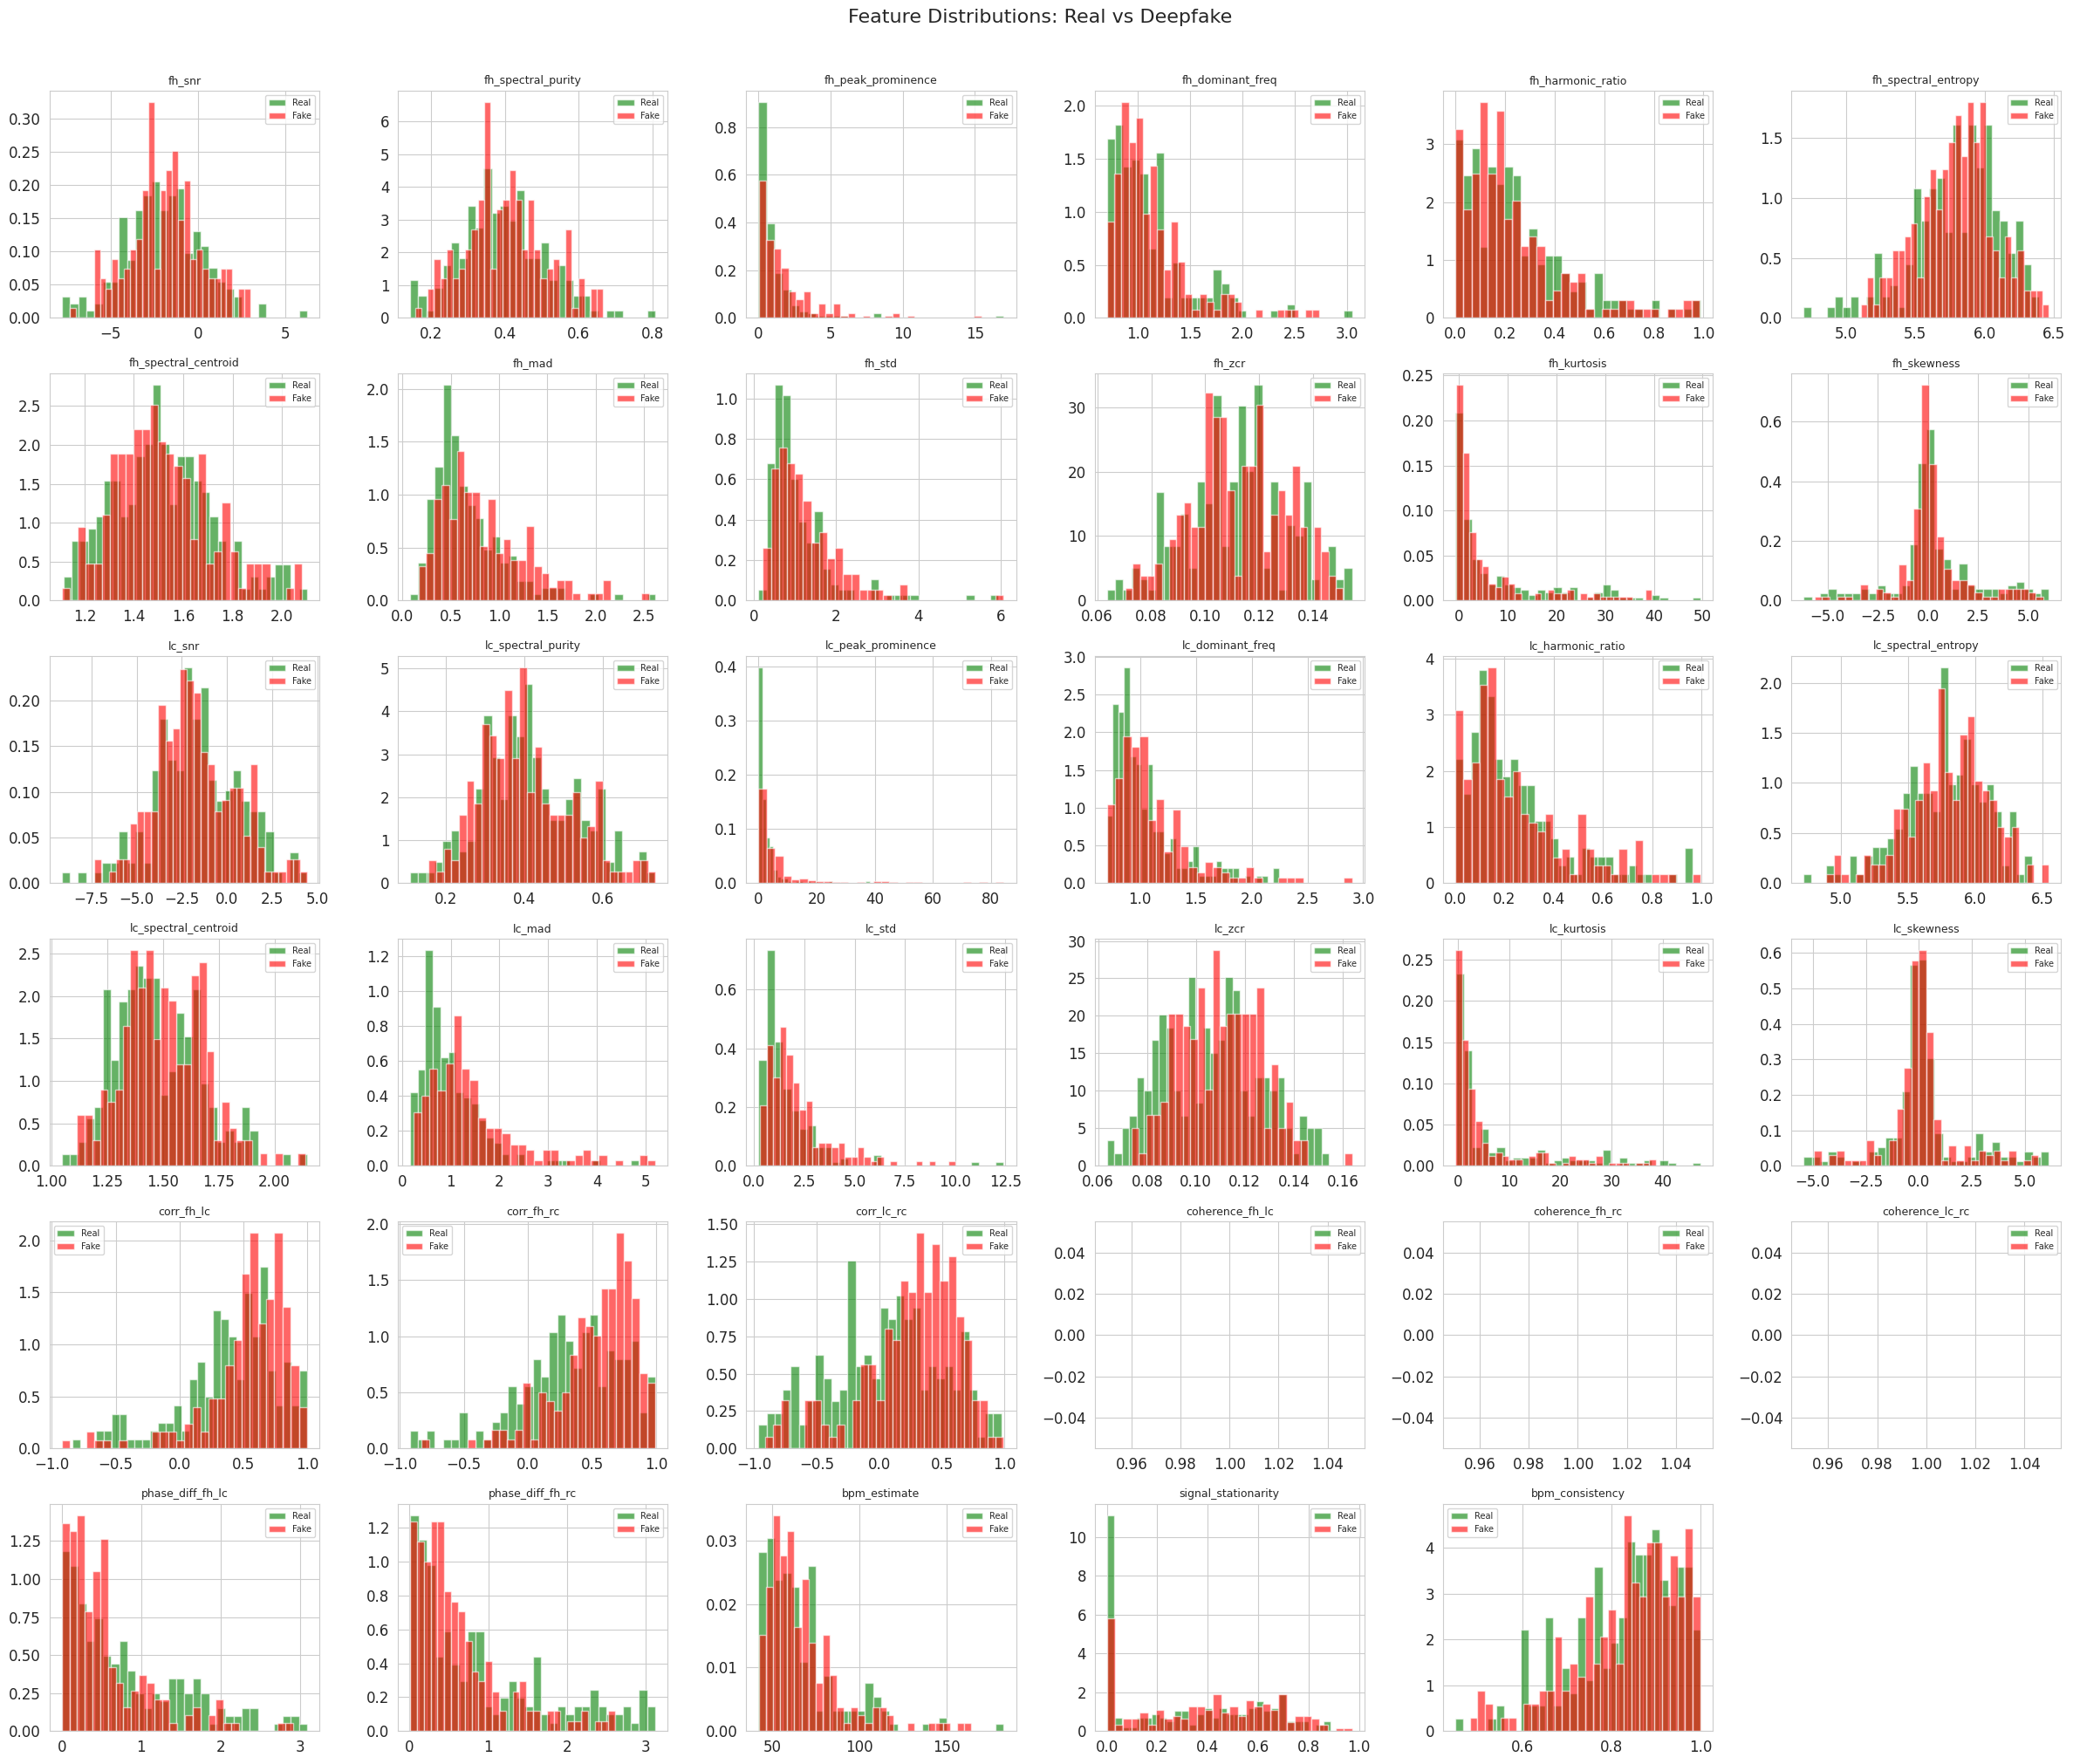

In [8]:
# ─── Feature Distributions: Real vs Fake ─────────────────────────
fig, axes = plt.subplots(6, 6, figsize=(24, 20))
axes = axes.flatten()

for i, fname in enumerate(FEATURE_NAMES):
    ax = axes[i]
    ax.hist(X[y==0, i], bins=30, alpha=0.6, label='Real', color='green', density=True)
    ax.hist(X[y==1, i], bins=30, alpha=0.6, label='Fake', color='red', density=True)
    ax.set_title(fname, fontsize=9)
    ax.legend(fontsize=7)

# Hide extra subplot
axes[35].set_visible(False)

plt.suptitle('Feature Distributions: Real vs Deepfake', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'feature_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

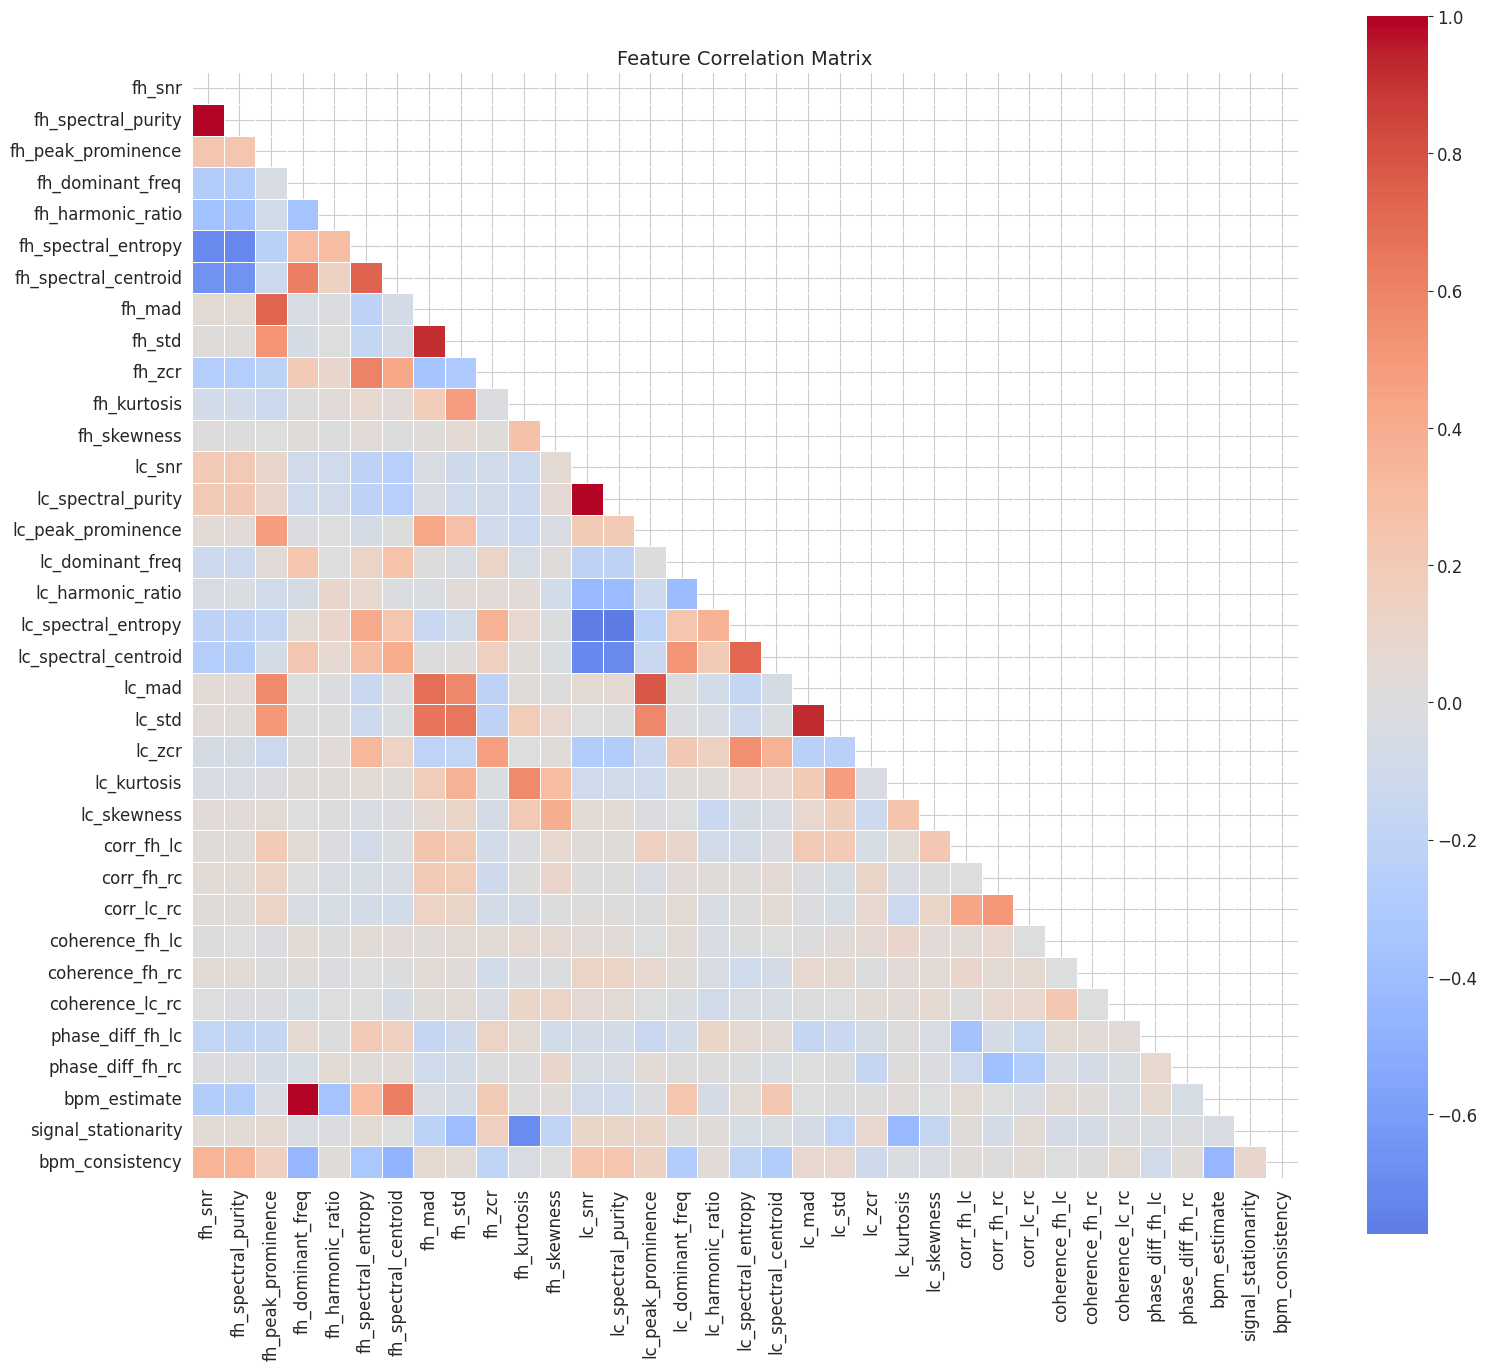

In [9]:
# ─── Correlation Matrix ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 14))
corr = df[FEATURE_NAMES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'correlation_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Data Preprocessing

In [10]:
# ─── Train/Test Split + Scaling ──────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape}")
print(f"Train class dist: Real={np.sum(y_train==0)}, Fake={np.sum(y_train==1)}")
print(f"Test  class dist: Real={np.sum(y_test==0)}, Fake={np.sum(y_test==1)}")

# Save scaler for inference
joblib.dump(scaler, os.path.join(OUTPUT_DIR, 'scaler.joblib'))
print("Scaler saved.")

Train: (314, 35) | Test: (79, 35)
Train class dist: Real=157, Fake=157
Test  class dist: Real=40, Fake=39
Scaler saved.


## 5. Model Definitions (Pre-Tuned Hyperparameters — No Grid Search)

In [11]:
# ─── All models with FIXED pre-tuned hyperparameters ─────────────
# No GridSearchCV = no crash, finishes in minutes.

SEED = 42

models = {
    'RandomForest': RandomForestClassifier(
        n_estimators=300, max_depth=20, min_samples_split=5,
        min_samples_leaf=2, max_features='sqrt',
        random_state=SEED, n_jobs=-1,
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=2.0,
        eval_metric='logloss', random_state=SEED, n_jobs=-1,
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=300, max_depth=10, learning_rate=0.05,
        num_leaves=63, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        random_state=SEED, n_jobs=-1, verbose=-1,
    ),
    'SVM_RBF': SVC(
        C=10.0, gamma='scale', kernel='rbf',
        probability=True, random_state=SEED,
    ),
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, min_samples_split=5,
        random_state=SEED,
    ),
    'ExtraTrees': ExtraTreesClassifier(
        n_estimators=300, max_depth=20, min_samples_split=5,
        max_features='sqrt', random_state=SEED, n_jobs=-1,
    ),
    'LogisticRegression': LogisticRegression(
        C=1.0, penalty='l2', solver='saga',
        max_iter=2000, random_state=SEED,
    ),
}

print(f"Defined {len(models)} models (pre-tuned, no grid search).")
for name, model in models.items():
    print(f"  {name}")

Defined 7 models (pre-tuned, no grid search).
  RandomForest
  XGBoost
  LightGBM
  SVM_RBF
  GradientBoosting
  ExtraTrees
  LogisticRegression


## 6. Train All Models (Direct Fit + 3-Fold CV)

In [12]:
# ─── Train each model: fit on train, evaluate on test ────────────
# Also run quick 3-fold CV for reporting in the paper.

from sklearn.model_selection import cross_val_score

results = {}
best_models = {}

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training: {name}")
    print(f"{'='*60}")
    
    t0 = time()
    
    # 3-fold CV on training set (for paper reporting)
    cv_scores = cross_val_score(model, X_train_scaled, y_train,
                                cv=3, scoring='roc_auc', n_jobs=-1)
    
    # Fit on full training set
    model.fit(X_train_scaled, y_train)
    
    elapsed = time() - t0
    
    # Evaluate on test set
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)
    
    results[name] = {
        'accuracy': acc, 'precision': prec, 'recall': rec,
        'f1': f1, 'auc': auc,
        'cv_auc_mean': cv_scores.mean(),
        'cv_auc_std': cv_scores.std(),
        'time': elapsed,
    }
    best_models[name] = model
    
    print(f"  CV AUC: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
    print(f"  Test Accuracy: {acc:.4f}")
    print(f"  Test AUC: {auc:.4f}")
    print(f"  Test F1: {f1:.4f}")
    print(f"  Time: {elapsed:.1f}s")
    
    # Save model
    joblib.dump(model, os.path.join(OUTPUT_DIR, f'{name}_best.joblib'))

print("\n" + "="*60)
print("All models trained and saved!")
print("="*60)


Training: RandomForest
  CV AUC: 0.7731 +/- 0.0744
  Test Accuracy: 0.5949
  Test AUC: 0.6923
  Test F1: 0.5152
  Time: 3.4s

Training: XGBoost
  CV AUC: 0.7456 +/- 0.0598
  Test Accuracy: 0.6582
  Test AUC: 0.7115
  Test F1: 0.5846
  Time: 1.8s

Training: LightGBM


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  CV AUC: 0.7364 +/- 0.0631
  Test Accuracy: 0.6582
  Test AUC: 0.7192
  Test F1: 0.5970
  Time: 50.6s

Training: SVM_RBF
  CV AUC: 0.7162 +/- 0.0499
  Test Accuracy: 0.5949
  Test AUC: 0.6119
  Test F1: 0.5556
  Time: 0.1s

Training: GradientBoosting
  CV AUC: 0.7604 +/- 0.0516
  Test Accuracy: 0.6076
  Test AUC: 0.7090
  Test F1: 0.5507
  Time: 3.7s

Training: ExtraTrees
  CV AUC: 0.7630 +/- 0.0377
  Test Accuracy: 0.6329
  Test AUC: 0.7077
  Test F1: 0.5538
  Time: 1.2s

Training: LogisticRegression
  CV AUC: 0.7115 +/- 0.0231
  Test Accuracy: 0.6456
  Test AUC: 0.7423
  Test F1: 0.5882
  Time: 0.1s

All models trained and saved!


## 7. Ensemble Model (Soft Voting — Top 3 by AUC)

In [13]:
# ─── Build ensemble from top-3 models by AUC ────────────────────

sorted_models = sorted(results.items(), key=lambda x: x[1]['auc'], reverse=True)
top3_names = [name for name, _ in sorted_models[:3]]

print(f"Top 3 models by AUC: {top3_names}")
for name in top3_names:
    print(f"  {name}: AUC={results[name]['auc']:.4f}")

# Create voting ensemble
ensemble_estimators = [(name, best_models[name]) for name in top3_names]
ensemble = VotingClassifier(
    estimators=ensemble_estimators,
    voting='soft',
    n_jobs=-1,
)

# Train ensemble (re-fits on training data)
ensemble.fit(X_train_scaled, y_train)

# Evaluate
y_pred_ens = ensemble.predict(X_test_scaled)
y_prob_ens = ensemble.predict_proba(X_test_scaled)[:, 1]

ens_acc = accuracy_score(y_test, y_pred_ens)
ens_auc = roc_auc_score(y_test, y_prob_ens)
ens_f1 = f1_score(y_test, y_pred_ens)
ens_prec = precision_score(y_test, y_pred_ens)
ens_rec = recall_score(y_test, y_pred_ens)

results['Ensemble_Top3'] = {
    'accuracy': ens_acc, 'precision': ens_prec, 'recall': ens_rec,
    'f1': ens_f1, 'auc': ens_auc,
    'cv_auc_mean': None,  # No CV for ensemble
    'cv_auc_std': None,
    'time': None,
}
best_models['Ensemble_Top3'] = ensemble

print(f"\nEnsemble Accuracy: {ens_acc:.4f}")
print(f"Ensemble AUC: {ens_auc:.4f}")
print(f"Ensemble F1: {ens_f1:.4f}")
print(f"Members: {top3_names}")

joblib.dump(ensemble, os.path.join(OUTPUT_DIR, 'Ensemble_Top3_best.joblib'))

Top 3 models by AUC: ['LogisticRegression', 'LightGBM', 'XGBoost']
  LogisticRegression: AUC=0.7423
  LightGBM: AUC=0.7192
  XGBoost: AUC=0.7115

Ensemble Accuracy: 0.6709
Ensemble AUC: 0.7365
Ensemble F1: 0.6061
Members: ['LogisticRegression', 'LightGBM', 'XGBoost']


['/kaggle/working/features/Ensemble_Top3_best.joblib']

## 8. Results Comparison Table

In [14]:
# ─── Results Table ───────────────────────────────────────────────

results_df = pd.DataFrame(results).T
results_df = results_df[['accuracy', 'precision', 'recall', 'f1', 'auc', 'cv_auc_mean', 'cv_auc_std', 'time']]
results_df = results_df.sort_values('auc', ascending=False)

display_df = results_df.copy()
for col in ['accuracy', 'precision', 'recall', 'f1', 'auc']:
    display_df[col] = display_df[col].apply(lambda x: f"{x:.4f}" if pd.notna(x) and x is not None else "-")
for col in ['cv_auc_mean', 'cv_auc_std']:
    display_df[col] = display_df[col].apply(lambda x: f"{x:.4f}" if pd.notna(x) and x is not None else "-")
display_df['time'] = display_df['time'].apply(lambda x: f"{x:.1f}s" if pd.notna(x) and x is not None else "-")

print("\n" + "="*80)
print("MODEL COMPARISON — SORTED BY AUC")
print("="*80)
print(display_df.to_string())

# Save results
results_df.to_csv(os.path.join(OUTPUT_DIR, 'ml_results.csv'))
print(f"\nResults saved to {OUTPUT_DIR}/ml_results.csv")


MODEL COMPARISON — SORTED BY AUC
                   accuracy precision  recall      f1     auc cv_auc_mean cv_auc_std   time
LogisticRegression   0.6456    0.6897  0.5128  0.5882  0.7423      0.7115     0.0231   0.1s
Ensemble_Top3        0.6709    0.7407  0.5128  0.6061  0.7365           -          -      -
LightGBM             0.6582    0.7143  0.5128  0.5970  0.7192      0.7364     0.0631  50.6s
XGBoost              0.6582    0.7308  0.4872  0.5846  0.7115      0.7456     0.0598   1.8s
GradientBoosting     0.6076    0.6333  0.4872  0.5507  0.7090      0.7604     0.0516   3.7s
ExtraTrees           0.6329    0.6923  0.4615  0.5538  0.7077      0.7630     0.0377   1.2s
RandomForest         0.5949    0.6296  0.4359  0.5152  0.6923      0.7731     0.0744   3.4s
SVM_RBF              0.5949    0.6061  0.5128  0.5556  0.6119      0.7162     0.0499   0.1s

Results saved to /kaggle/working/features/ml_results.csv


## 9. Visualization: ROC Curves, Confusion Matrices, Feature Importance

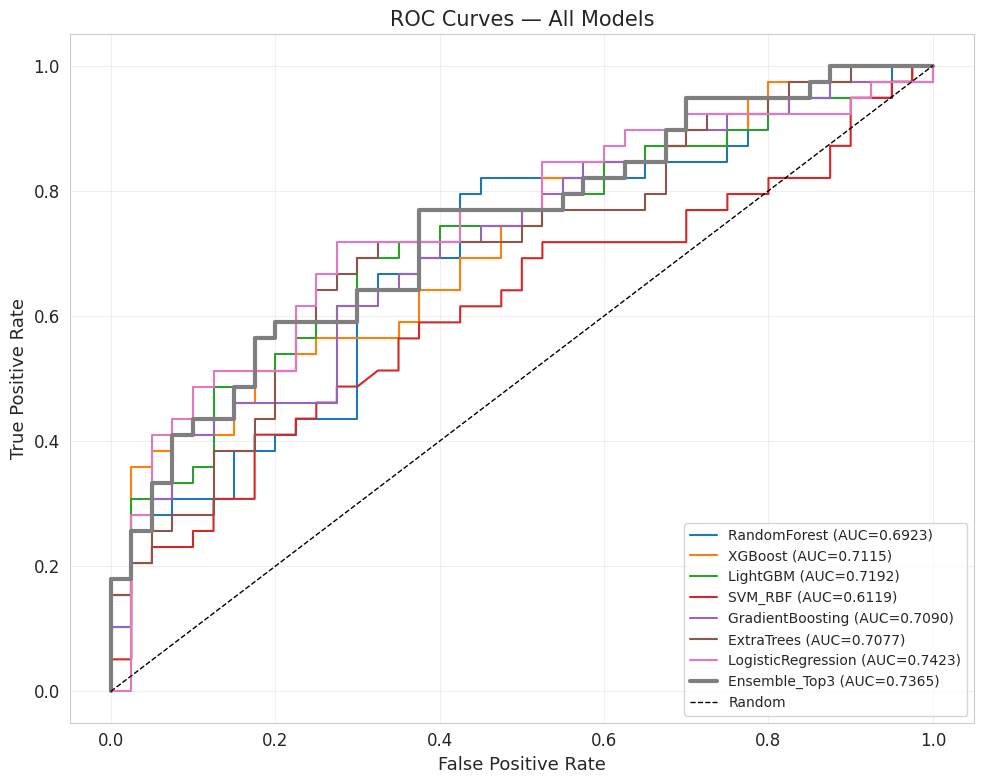

In [15]:
# ─── ROC Curves for All Models ───────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 8))

for name, model in best_models.items():
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    lw = 3 if 'Ensemble' in name else 1.5
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.4f})", linewidth=lw)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curves — All Models', fontsize=15)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'roc_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

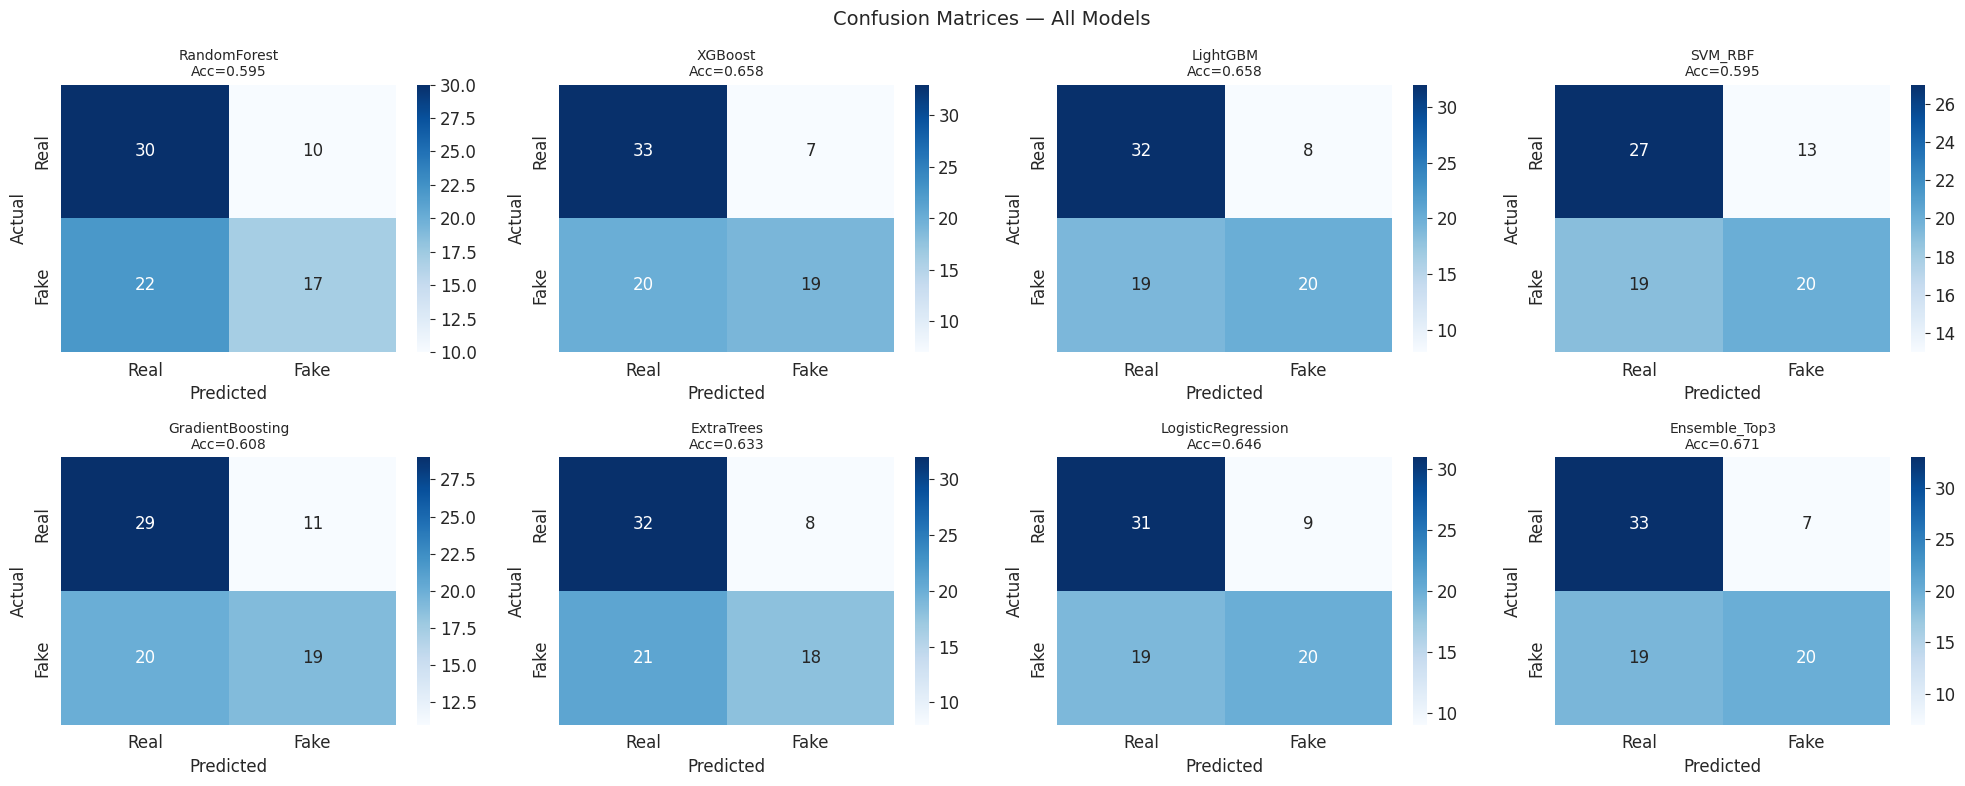

In [16]:
# ─── Confusion Matrices ──────────────────────────────────────────

n_models = len(best_models)
cols = 4
rows = (n_models + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
axes = axes.flatten()

for i, (name, model) in enumerate(best_models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
    axes[i].set_title(f'{name}\nAcc={accuracy_score(y_test, y_pred):.3f}', fontsize=10)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices — All Models', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()

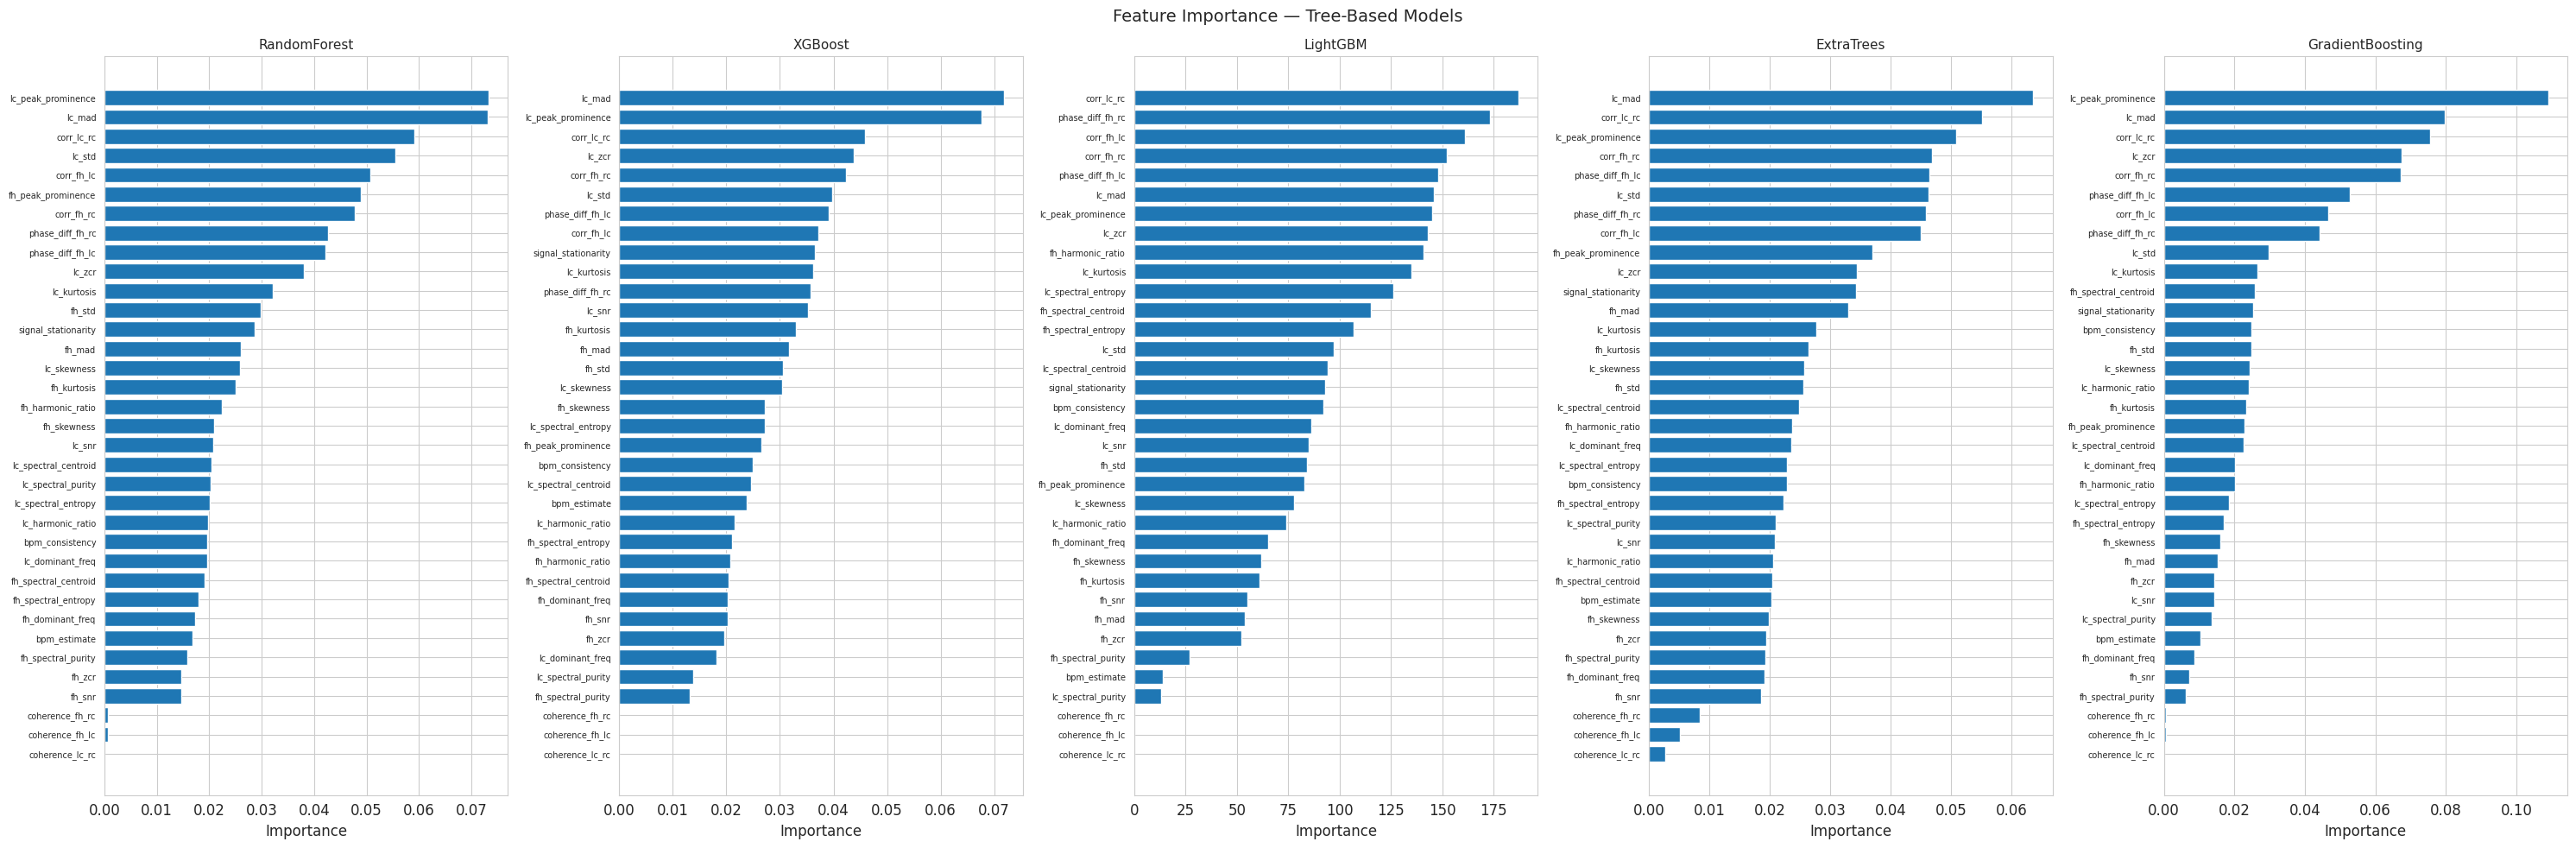

In [17]:
# ─── Feature Importance (from tree-based models) ─────────────────

tree_models = ['RandomForest', 'XGBoost', 'LightGBM', 'ExtraTrees', 'GradientBoosting']

fig, axes = plt.subplots(1, len(tree_models), figsize=(6*len(tree_models), 10))

for i, name in enumerate(tree_models):
    model = best_models[name]
    importance = model.feature_importances_
    sorted_idx = np.argsort(importance)
    
    axes[i].barh(range(len(sorted_idx)), importance[sorted_idx], align='center')
    axes[i].set_yticks(range(len(sorted_idx)))
    axes[i].set_yticklabels([FEATURE_NAMES[j] for j in sorted_idx], fontsize=7)
    axes[i].set_title(f'{name}', fontsize=11)
    axes[i].set_xlabel('Importance')

plt.suptitle('Feature Importance — Tree-Based Models', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

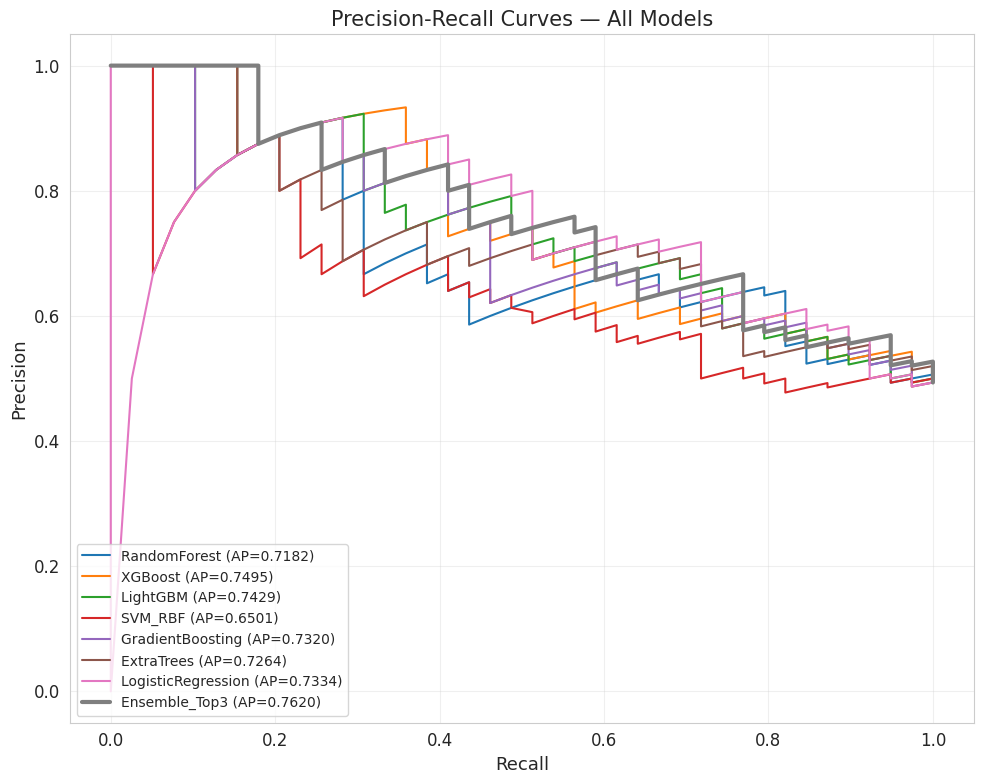

In [18]:
# ─── Precision-Recall Curves ─────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 8))

for name, model in best_models.items():
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    lw = 3 if 'Ensemble' in name else 1.5
    ax.plot(rec_vals, prec_vals, label=f"{name} (AP={ap:.4f})", linewidth=lw)

ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('Precision-Recall Curves — All Models', fontsize=15)
ax.legend(loc='lower left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'precision_recall_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

## 10. Best Model Classification Report

In [19]:
# ─── Detailed report for the best model ──────────────────────────

best_name = results_df.index[0]
best_model = best_models[best_name]

y_pred_best = best_model.predict(X_test_scaled)
y_prob_best = best_model.predict_proba(X_test_scaled)[:, 1]

print(f"{'='*60}")
print(f"BEST MODEL: {best_name}")
print(f"{'='*60}")
print(f"\nTest AUC: {roc_auc_score(y_test, y_prob_best):.4f}")

# CV AUC — only available for individual models, not Ensemble
cv_mean = results[best_name].get('cv_auc_mean')
cv_std = results[best_name].get('cv_auc_std')
if cv_mean is not None and cv_std is not None:
    print(f"CV AUC: {cv_mean:.4f} +/- {cv_std:.4f}")
else:
    print(f"CV AUC: N/A (ensemble of top-3 models)")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Real', 'Deepfake']))

BEST MODEL: LogisticRegression

Test AUC: 0.7423
CV AUC: 0.7115 +/- 0.0231

Classification Report:
              precision    recall  f1-score   support

        Real       0.62      0.78      0.69        40
    Deepfake       0.69      0.51      0.59        39

    accuracy                           0.65        79
   macro avg       0.65      0.64      0.64        79
weighted avg       0.65      0.65      0.64        79



## 11. Save Everything for Deep Learning Notebook

In [20]:
# ─── Save all artifacts ──────────────────────────────────────────

# Save train/test split for consistency with DL notebook
np.save(os.path.join(OUTPUT_DIR, 'X_train.npy'), X_train)
np.save(os.path.join(OUTPUT_DIR, 'X_test.npy'), X_test)
np.save(os.path.join(OUTPUT_DIR, 'y_train.npy'), y_train)
np.save(os.path.join(OUTPUT_DIR, 'y_test.npy'), y_test)
np.save(os.path.join(OUTPUT_DIR, 'X_train_scaled.npy'), X_train_scaled)
np.save(os.path.join(OUTPUT_DIR, 'X_test_scaled.npy'), X_test_scaled)

print("Saved artifacts:")
for f in os.listdir(OUTPUT_DIR):
    fpath = os.path.join(OUTPUT_DIR, f)
    size_mb = os.path.getsize(fpath) / 1024 / 1024
    print(f"  {f}: {size_mb:.2f} MB")

print(f"\nTotal models saved: {len(best_models)}")
print("ML training complete. Proceed to Deep Learning notebook for DL models.")

Saved artifacts:
  GradientBoosting_best.joblib: 0.85 MB
  feature_importance.png: 0.28 MB
  labels.npy: 0.00 MB
  y_test.npy: 0.00 MB
  X_train_scaled.npy: 0.08 MB
  X_train.npy: 0.08 MB
  features.npy: 0.11 MB
  y_train.npy: 0.00 MB
  ExtraTrees_best.joblib: 4.66 MB
  RandomForest_best.joblib: 1.79 MB
  scaler.joblib: 0.00 MB
  X_test_scaled.npy: 0.02 MB
  features.csv: 0.23 MB
  LogisticRegression_best.joblib: 0.00 MB
  X_test.npy: 0.02 MB
  roc_curves.png: 0.12 MB
  XGBoost_best.joblib: 0.42 MB
  LightGBM_best.joblib: 0.39 MB
  correlation_matrix.png: 0.24 MB
  ml_results.csv: 0.00 MB
  feature_distributions.png: 0.49 MB
  precision_recall_curves.png: 0.15 MB
  confusion_matrices.png: 0.15 MB
  Ensemble_Top3_best.joblib: 1.62 MB
  SVM_RBF_best.joblib: 0.07 MB

Total models saved: 8
ML training complete. Proceed to Deep Learning notebook for DL models.


In [21]:
import shutil

shutil.make_archive("model_outputs", 'zip', "/kaggle/working")

'/kaggle/working/model_outputs.zip'

# Neuro-Pulse: rPPG-Based Deepfake Detection — Deep Learning Training
## Kaggle P100 Optimized (Won't Crash)

**5 DL architectures** + **ensemble** on 35-dim rPPG features.
- **60 epochs max** with early stopping (patience=10)
- **GPU memory cleared** between models
- **Smaller hidden dims** to fit P100 16GB comfortably
- Total runtime: ~15-30 minutes on Kaggle P100

**Models:** 1D-CNN, BiLSTM+Attention, CNN-BiLSTM, Transformer, PhysNet-MLP

**References:**
- DeepFakesON-Phys (Hernandez-Ortega et al., 2020)
- FakeCatcher (Ciftci et al., TPAMI 2020)
- pyVHR (Boccignone et al., 2022)
- rPPG-Toolbox (Liu et al., NeurIPS 2023)

## 1. Setup & Imports

In [23]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from time import time

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts, ReduceLROnPlateau

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PyTorch: 2.9.0+cu126
Device: cuda
GPU: Tesla P100-PCIE-16GB
VRAM: 17.1 GB


## 2. Load Data

In [25]:
# ─── Load features ───────────────────────────────────────────────
# Works in 3 scenarios:
#   A) Same Kaggle session as ML notebook → loads from /kaggle/working/features
#   B) Separate session, features uploaded as dataset → loads from /kaggle/input
#   C) Neither found → prints clear instructions

OUTPUT_DIR = "/kaggle/working/features"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Search order for feature files
search_paths = [
    "/kaggle/working/features",            # Same session as ML notebook
    "/kaggle/input/neuropulse-features",    # If you saved features as a Kaggle dataset
    "/kaggle/input/features",              # Generic
]

features_path = None
for sp in search_paths:
    fp = os.path.join(sp, "features.npy")
    lp = os.path.join(sp, "labels.npy")
    if os.path.exists(fp) and os.path.exists(lp):
        features_path = sp
        break

# Also check for pre-split data
splits_found = False
if features_path:
    splits_found = os.path.exists(os.path.join(features_path, "X_train.npy"))

if features_path is None:
    print("="*60)
    print("ERROR: Feature files not found!")
    print("="*60)
    print("\nOptions:")
    print("  1. Run 01_ml_training.ipynb FIRST in the same Kaggle session")
    print("  2. Upload features.npy and labels.npy as a Kaggle dataset")
    print(f"\nSearched in: {search_paths}")
    raise FileNotFoundError("Run ML notebook first to extract features.")

print(f"Found features at: {features_path}")

if splits_found:
    X_train = np.load(os.path.join(features_path, 'X_train.npy'))
    X_test = np.load(os.path.join(features_path, 'X_test.npy'))
    y_train = np.load(os.path.join(features_path, 'y_train.npy'))
    y_test = np.load(os.path.join(features_path, 'y_test.npy'))
    print("Loaded pre-split data (consistent with ML notebook).")
else:
    X = np.load(os.path.join(features_path, 'features.npy'))
    y = np.load(os.path.join(features_path, 'labels.npy'))
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y
    )
    print("Loaded raw features and split 80/20.")

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Validation split from training
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.15, random_state=SEED, stratify=y_train
)

print(f"\nTrain: {X_tr.shape} | Val: {X_val.shape} | Test: {X_test_scaled.shape}")
print(f"Train: Real={np.sum(y_tr==0)}, Fake={np.sum(y_tr==1)}")
print(f"Val:   Real={np.sum(y_val==0)}, Fake={np.sum(y_val==1)}")
print(f"Test:  Real={np.sum(y_test==0)}, Fake={np.sum(y_test==1)}")

N_FEATURES = X_tr.shape[1]
print(f"\nFeature dimension: {N_FEATURES}")

Found features at: /kaggle/working/features
Loaded pre-split data (consistent with ML notebook).

Train: (266, 35) | Val: (48, 35) | Test: (79, 35)
Train: Real=133, Fake=133
Val:   Real=24, Fake=24
Test:  Real=40, Fake=39

Feature dimension: 35


In [26]:
# ─── Create PyTorch DataLoaders ──────────────────────────────────

BATCH_SIZE = 32

# Weighted sampler for class imbalance
class_counts = np.bincount(y_tr)
class_weights = 1.0 / class_counts
sample_weights = class_weights[y_tr]
sampler = WeightedRandomSampler(
    weights=sample_weights, num_samples=len(sample_weights), replacement=True
)

# Tensors
train_dataset = TensorDataset(
    torch.FloatTensor(X_tr), torch.LongTensor(y_tr)
)
val_dataset = TensorDataset(
    torch.FloatTensor(X_val), torch.LongTensor(y_val)
)
test_dataset = TensorDataset(
    torch.FloatTensor(X_test_scaled), torch.LongTensor(y_test)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler, drop_last=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 9
Val batches: 2
Test batches: 3


## 3. Model Architectures

In [27]:
# ═══════════════════════════════════════════════════════════════════
# MODEL 1: 1D-CNN (reduced for Kaggle)
# ═══════════════════════════════════════════════════════════════════

class DeepfakeCNN1D(nn.Module):
    """
    1D Convolutional Neural Network for rPPG feature classification.
    Treats the 35 features as a 1D signal and applies conv filters
    to capture local feature interactions.
    """
    def __init__(self, n_features=35, dropout=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 2),
        )
    
    def forward(self, x):
        x = x.unsqueeze(1)  # (batch, 1, 35)
        x = self.features(x)
        x = self.classifier(x)
        return x


print("Model 1: DeepfakeCNN1D")
m = DeepfakeCNN1D(N_FEATURES).to(device)
print(f"  Parameters: {sum(p.numel() for p in m.parameters()):,}")
del m

Model 1: DeepfakeCNN1D
  Parameters: 39,874


In [28]:
# ═══════════════════════════════════════════════════════════════════
# MODEL 2: BiLSTM with Attention (reduced for Kaggle)
# ═══════════════════════════════════════════════════════════════════

class Attention(nn.Module):
    """Scaled dot-product attention over LSTM outputs."""
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)
    
    def forward(self, lstm_out):
        scores = self.attn(lstm_out).squeeze(-1)
        weights = torch.softmax(scores, dim=-1)
        context = torch.bmm(weights.unsqueeze(1), lstm_out).squeeze(1)
        return context, weights


class DeepfakeBiLSTM(nn.Module):
    """
    Bidirectional LSTM with attention for rPPG features.
    Reshapes 35 features into 7 groups of 5.
    Reduced: hidden_dim=64, 2 layers.
    """
    def __init__(self, n_features=35, hidden_dim=64, n_layers=2, dropout=0.3):
        super().__init__()
        self.seq_len = 7
        self.feat_per_step = 5
        
        self.input_proj = nn.Linear(self.feat_per_step, hidden_dim)
        self.lstm = nn.LSTM(
            input_size=hidden_dim, hidden_size=hidden_dim,
            num_layers=n_layers, batch_first=True,
            bidirectional=True, dropout=dropout if n_layers > 1 else 0,
        )
        self.attention = Attention(hidden_dim * 2)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 2),
        )
    
    def forward(self, x):
        batch_size = x.size(0)
        x = x.view(batch_size, self.seq_len, self.feat_per_step)
        x = self.input_proj(x)
        lstm_out, _ = self.lstm(x)
        context, _ = self.attention(lstm_out)
        return self.classifier(context)


print("Model 2: DeepfakeBiLSTM")
m = DeepfakeBiLSTM(N_FEATURES).to(device)
print(f"  Parameters: {sum(p.numel() for p in m.parameters()):,}")
del m

Model 2: DeepfakeBiLSTM
  Parameters: 174,787


In [29]:
# ═══════════════════════════════════════════════════════════════════
# MODEL 3: CNN-BiLSTM Hybrid (reduced for Kaggle)
# ═══════════════════════════════════════════════════════════════════

class DeepfakeCNNBiLSTM(nn.Module):
    """
    Hybrid: 1D-CNN extracts local feature patterns,
    BiLSTM captures sequential dependencies.
    Reduced: cnn_channels=32, lstm_hidden=64.
    """
    def __init__(self, n_features=35, cnn_channels=32, lstm_hidden=64,
                 lstm_layers=2, dropout=0.3):
        super().__init__()
        
        self.cnn = nn.Sequential(
            nn.Conv1d(1, cnn_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(cnn_channels),
            nn.ReLU(),
            nn.Conv1d(cnn_channels, cnn_channels * 2, kernel_size=3, padding=1),
            nn.BatchNorm1d(cnn_channels * 2),
            nn.ReLU(),
        )
        
        self.lstm = nn.LSTM(
            input_size=cnn_channels * 2, hidden_size=lstm_hidden,
            num_layers=lstm_layers, batch_first=True,
            bidirectional=True, dropout=dropout if lstm_layers > 1 else 0,
        )
        self.attention = Attention(lstm_hidden * 2)
        
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 2),
        )
    
    def forward(self, x):
        x = x.unsqueeze(1)
        cnn_out = self.cnn(x)
        cnn_out = cnn_out.permute(0, 2, 1)
        lstm_out, _ = self.lstm(cnn_out)
        context, _ = self.attention(lstm_out)
        return self.classifier(context)


print("Model 3: DeepfakeCNNBiLSTM")
m = DeepfakeCNNBiLSTM(N_FEATURES).to(device)
print(f"  Parameters: {sum(p.numel() for p in m.parameters()):,}")
del m

Model 3: DeepfakeCNNBiLSTM
  Parameters: 180,931


In [30]:
# ═══════════════════════════════════════════════════════════════════
# MODEL 4: Transformer Encoder (reduced for Kaggle)
# ═══════════════════════════════════════════════════════════════════

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        if d_model > 1:
            pe[:, 1::2] = torch.cos(position * div_term[:d_model//2])
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class DeepfakeTransformer(nn.Module):
    """
    Transformer Encoder for rPPG feature classification.
    Reshapes 35 features into 7 groups of 5, applies multi-head
    self-attention to learn cross-group feature interactions.
    Reduced: d_model=32, 2 layers, dim_ff=128.
    """
    def __init__(self, n_features=35, d_model=32, nhead=4,
                 num_layers=2, dim_ff=128, dropout=0.3):
        super().__init__()
        self.seq_len = 7
        self.feat_per_step = 5
        
        self.input_proj = nn.Linear(self.feat_per_step, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len=self.seq_len)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, activation='gelu', batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=num_layers
        )
        
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 2),
        )
    
    def forward(self, x):
        batch_size = x.size(0)
        x = x.view(batch_size, self.seq_len, self.feat_per_step)
        x = self.input_proj(x)
        x = self.pos_enc(x)
        x = self.transformer(x)
        x = x.mean(dim=1)  # Global average pooling
        return self.classifier(x)


print("Model 4: DeepfakeTransformer")
m = DeepfakeTransformer(N_FEATURES).to(device)
print(f"  Parameters: {sum(p.numel() for p in m.parameters()):,}")
del m

Model 4: DeepfakeTransformer
  Parameters: 27,906


In [31]:
# ═══════════════════════════════════════════════════════════════════
# MODEL 5: PhysNet-Inspired Deep Residual MLP (reduced for Kaggle)
# ═══════════════════════════════════════════════════════════════════

class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
        )
        self.act = nn.GELU()
    
    def forward(self, x):
        return self.act(x + self.block(x))


class PhysNetMLP(nn.Module):
    """
    Deep Residual MLP inspired by DeepFakesON-Phys CAN architecture.
    Reduced size for Kaggle P100.
    """
    def __init__(self, n_features=35, hidden_dim=128, n_blocks=3, dropout=0.3):
        super().__init__()
        
        self.input_proj = nn.Sequential(
            nn.Linear(n_features, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        
        self.res_blocks = nn.Sequential(
            *[ResidualBlock(hidden_dim, dropout * 0.7) for _ in range(n_blocks)]
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 2),
        )
    
    def forward(self, x):
        x = self.input_proj(x)
        x = self.res_blocks(x)
        return self.classifier(x)


print("Model 5: PhysNetMLP")
m = PhysNetMLP(N_FEATURES).to(device)
print(f"  Parameters: {sum(p.numel() for p in m.parameters()):,}")
del m

Model 5: PhysNetMLP
  Parameters: 113,858


## 4. Training Infrastructure

In [32]:
# ─── Training and Evaluation Functions (Kaggle-safe) ─────────────

import gc

class EarlyStopping:
    """Stop training when validation loss stops improving."""
    def __init__(self, patience=10, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.should_stop = False
        self.best_state = None
    
    def __call__(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True


def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == y_batch).sum().item()
        total += X_batch.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_probs, all_labels = [], []
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        total_loss += loss.item() * X_batch.size(0)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        correct += (preds == y_batch).sum().item()
        total += X_batch.size(0)
        all_probs.append(probs[:, 1].cpu().numpy())
        all_labels.append(y_batch.cpu().numpy())
    
    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    return total_loss / total, correct / total, all_probs, all_labels


def train_model(model, name, train_loader, val_loader, test_loader,
                epochs=60, lr=1e-3, weight_decay=1e-4):
    """
    Training pipeline — Kaggle P100 safe:
    - 60 epochs max, early stopping patience=10
    - GPU cache cleared after training
    """
    print(f"\n{'='*70}")
    print(f"Training: {name}")
    print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
    print(f"{'='*70}")
    
    # Class-weighted loss
    class_weights_tensor = torch.FloatTensor(
        [1.0 / class_counts[0], 1.0 / class_counts[1]]
    ).to(device)
    class_weights_tensor = class_weights_tensor / class_weights_tensor.sum()
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=15, T_mult=2, eta_min=1e-6)
    early_stop = EarlyStopping(patience=10)
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    t0 = time()
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step()
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        if epoch % 10 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{epochs} | "
                  f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
        
        early_stop(val_loss, model)
        if early_stop.should_stop:
            print(f"  Early stopping at epoch {epoch}")
            break
    
    elapsed = time() - t0
    print(f"  Training time: {elapsed:.1f}s")
    
    # Restore best model
    if early_stop.best_state is not None:
        model.load_state_dict(early_stop.best_state)
        model.to(device)
    
    # Final test evaluation
    test_loss, test_acc, test_probs, test_labels = evaluate(
        model, test_loader, criterion
    )
    test_preds = (test_probs >= 0.5).astype(int)
    
    test_auc = roc_auc_score(test_labels, test_probs)
    test_f1 = f1_score(test_labels, test_preds, zero_division=0)
    test_prec = precision_score(test_labels, test_preds, zero_division=0)
    test_rec = recall_score(test_labels, test_preds, zero_division=0)
    
    print(f"\n  Test Results:")
    print(f"    Accuracy:  {test_acc:.4f}")
    print(f"    AUC:       {test_auc:.4f}")
    print(f"    F1:        {test_f1:.4f}")
    print(f"    Precision: {test_prec:.4f}")
    print(f"    Recall:    {test_rec:.4f}")
    
    metrics = {
        'accuracy': test_acc, 'auc': test_auc, 'f1': test_f1,
        'precision': test_prec, 'recall': test_rec,
        'time': elapsed, 'epochs_trained': len(history['train_loss']),
        'best_val_loss': early_stop.best_loss,
    }
    
    return model, history, metrics, test_probs, test_labels


print("Training infrastructure ready (Kaggle-safe: 60 epochs, patience=10).")

Training infrastructure ready (Kaggle-safe: 60 epochs, patience=10).


## 5. Train All 5 Models

In [34]:
# ─── Define all models (Kaggle-safe sizes) ───────────────────────

EPOCHS = 60  # Max epochs (early stopping will kick in sooner)

dl_models = {
    'CNN_1D': {
        'model': DeepfakeCNN1D(N_FEATURES, dropout=0.3),
        'lr': 1e-3,
        'weight_decay': 1e-4,
    },
    'BiLSTM_Attention': {
        'model': DeepfakeBiLSTM(N_FEATURES, hidden_dim=64, n_layers=2, dropout=0.3),
        'lr': 5e-4,
        'weight_decay': 1e-4,
    },
    'CNN_BiLSTM': {
        'model': DeepfakeCNNBiLSTM(N_FEATURES, cnn_channels=32, lstm_hidden=64,
                                    lstm_layers=2, dropout=0.3),
        'lr': 5e-4,
        'weight_decay': 1e-4,
    },
    'Transformer': {
        'model': DeepfakeTransformer(N_FEATURES, d_model=32, nhead=4,
                                     num_layers=2, dim_ff=128, dropout=0.3),
        'lr': 1e-4,
        'weight_decay': 1e-3,
    },
    'PhysNet_MLP': {
        'model': PhysNetMLP(N_FEATURES, hidden_dim=128, n_blocks=3, dropout=0.3),
        'lr': 1e-3,
        'weight_decay': 5e-4,
    },
}

print(f"Models to train: {len(dl_models)}")
total_params = 0
for name, cfg in dl_models.items():
    n_params = sum(p.numel() for p in cfg['model'].parameters())
    total_params += n_params
    print(f"  {name}: {n_params:,} parameters | lr={cfg['lr']}")
print(f"\nTotal params across all models: {total_params:,}")
print(f"Max epochs per model: {EPOCHS} (with early stopping patience=10)")

Models to train: 5
  CNN_1D: 39,874 parameters | lr=0.001
  BiLSTM_Attention: 174,787 parameters | lr=0.0005
  CNN_BiLSTM: 180,931 parameters | lr=0.0005
  Transformer: 27,906 parameters | lr=0.0001
  PhysNet_MLP: 113,858 parameters | lr=0.001

Total params across all models: 537,356
Max epochs per model: 60 (with early stopping patience=10)


In [35]:
# ─── Train all models (with GPU cleanup between each) ────────────

dl_results = {}
dl_histories = {}
dl_trained_models = {}
dl_test_outputs = {}

for name, cfg in dl_models.items():
    # Clear GPU memory before each model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    model = cfg['model'].to(device)
    trained_model, history, metrics, test_probs, test_labels = train_model(
        model=model,
        name=name,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        epochs=EPOCHS,
        lr=cfg['lr'],
        weight_decay=cfg['weight_decay'],
    )
    
    dl_results[name] = metrics
    dl_histories[name] = history
    dl_test_outputs[name] = (test_probs, test_labels)
    
    # Save model checkpoint then move model to CPU to free GPU
    trained_model.cpu()
    torch.save({
        'model_state_dict': trained_model.state_dict(),
        'metrics': metrics,
        'config': {k: v for k, v in cfg.items() if k != 'model'},
    }, os.path.join(OUTPUT_DIR, f'{name}_checkpoint.pth'))
    dl_trained_models[name] = trained_model  # stored on CPU
    
    # Free GPU
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    print(f"  [GPU cleaned up]")

print("\n" + "="*70)
print("All DL models trained!")
print("="*70)


Training: CNN_1D
Parameters: 39,874
  Epoch   1/60 | Train Loss: 0.6789 Acc: 0.5827 | Val Loss: 0.6896 Acc: 0.5000
  Epoch  10/60 | Train Loss: 0.6342 Acc: 0.6466 | Val Loss: 0.6611 Acc: 0.5000
  Early stopping at epoch 15
  Training time: 2.6s

  Test Results:
    Accuracy:  0.6456
    AUC:       0.7077
    F1:        0.6500
    Precision: 0.6341
    Recall:    0.6667
  [GPU cleaned up]

Training: BiLSTM_Attention
Parameters: 174,787
  Epoch   1/60 | Train Loss: 0.6912 Acc: 0.5188 | Val Loss: 0.6914 Acc: 0.5000
  Epoch  10/60 | Train Loss: 0.5700 Acc: 0.7068 | Val Loss: 0.6058 Acc: 0.6667
  Epoch  20/60 | Train Loss: 0.5185 Acc: 0.7481 | Val Loss: 0.5873 Acc: 0.6250
  Epoch  30/60 | Train Loss: 0.5244 Acc: 0.7105 | Val Loss: 0.5836 Acc: 0.7292
  Epoch  40/60 | Train Loss: 0.4261 Acc: 0.7895 | Val Loss: 0.5489 Acc: 0.7500
  Early stopping at epoch 46
  Training time: 2.5s

  Test Results:
    Accuracy:  0.6456
    AUC:       0.6763
    F1:        0.6500
    Precision: 0.6341
    Recal

## 6. DL Ensemble (Average Probability)

In [36]:
# ─── Ensemble: Average probabilities from all 5 models ───────────

# Stack all test probabilities
all_probs = np.stack([dl_test_outputs[name][0] for name in dl_test_outputs])
ensemble_probs = np.mean(all_probs, axis=0)
ensemble_preds = (ensemble_probs >= 0.5).astype(int)
test_labels_ens = dl_test_outputs[list(dl_test_outputs.keys())[0]][1]

ens_acc = accuracy_score(test_labels_ens, ensemble_preds)
ens_auc = roc_auc_score(test_labels_ens, ensemble_probs)
ens_f1 = f1_score(test_labels_ens, ensemble_preds)
ens_prec = precision_score(test_labels_ens, ensemble_preds)
ens_rec = recall_score(test_labels_ens, ensemble_preds)

dl_results['DL_Ensemble'] = {
    'accuracy': ens_acc, 'auc': ens_auc, 'f1': ens_f1,
    'precision': ens_prec, 'recall': ens_rec,
    'time': sum(r['time'] for r in dl_results.values()),
    'epochs_trained': '-', 'best_val_loss': '-',
}

print(f"DL Ensemble Results:")
print(f"  Accuracy:  {ens_acc:.4f}")
print(f"  AUC:       {ens_auc:.4f}")
print(f"  F1:        {ens_f1:.4f}")
print(f"  Precision: {ens_prec:.4f}")
print(f"  Recall:    {ens_rec:.4f}")

DL Ensemble Results:
  Accuracy:  0.6582
  AUC:       0.7301
  F1:        0.6494
  Precision: 0.6579
  Recall:    0.6410


## 7. Results Comparison

In [37]:
# ─── Results Table ───────────────────────────────────────────────

dl_results_df = pd.DataFrame(dl_results).T
dl_results_df = dl_results_df[['accuracy', 'precision', 'recall', 'f1', 'auc', 'time', 'epochs_trained']]
dl_results_df = dl_results_df.sort_values('auc', ascending=False)

display_df = dl_results_df.copy()
for col in ['accuracy', 'precision', 'recall', 'f1', 'auc']:
    display_df[col] = display_df[col].apply(lambda x: f"{x:.4f}" if isinstance(x, float) else str(x))
display_df['time'] = display_df['time'].apply(lambda x: f"{x:.1f}s" if isinstance(x, float) else str(x))

print("\n" + "="*80)
print("DEEP LEARNING MODEL COMPARISON — SORTED BY AUC")
print("="*80)
print(display_df.to_string())

dl_results_df.to_csv(os.path.join(OUTPUT_DIR, 'dl_results.csv'))
print(f"\nResults saved to {OUTPUT_DIR}/dl_results.csv")


DEEP LEARNING MODEL COMPARISON — SORTED BY AUC
                 accuracy precision  recall      f1     auc   time epochs_trained
CNN_BiLSTM         0.6329    0.6316  0.6154  0.6234  0.7397   2.3s           40.0
DL_Ensemble        0.6582    0.6579  0.6410  0.6494  0.7301  12.1s              -
CNN_1D             0.6456    0.6341  0.6667  0.6500  0.7077   2.6s           15.0
PhysNet_MLP        0.6456    0.6571  0.5897  0.6216  0.6897   0.7s           14.0
BiLSTM_Attention   0.6456    0.6341  0.6667  0.6500  0.6763   2.5s           46.0
Transformer        0.5823    0.5938  0.4872  0.5352  0.6577   4.0s           60.0

Results saved to /kaggle/working/features/dl_results.csv


## 8. Visualizations

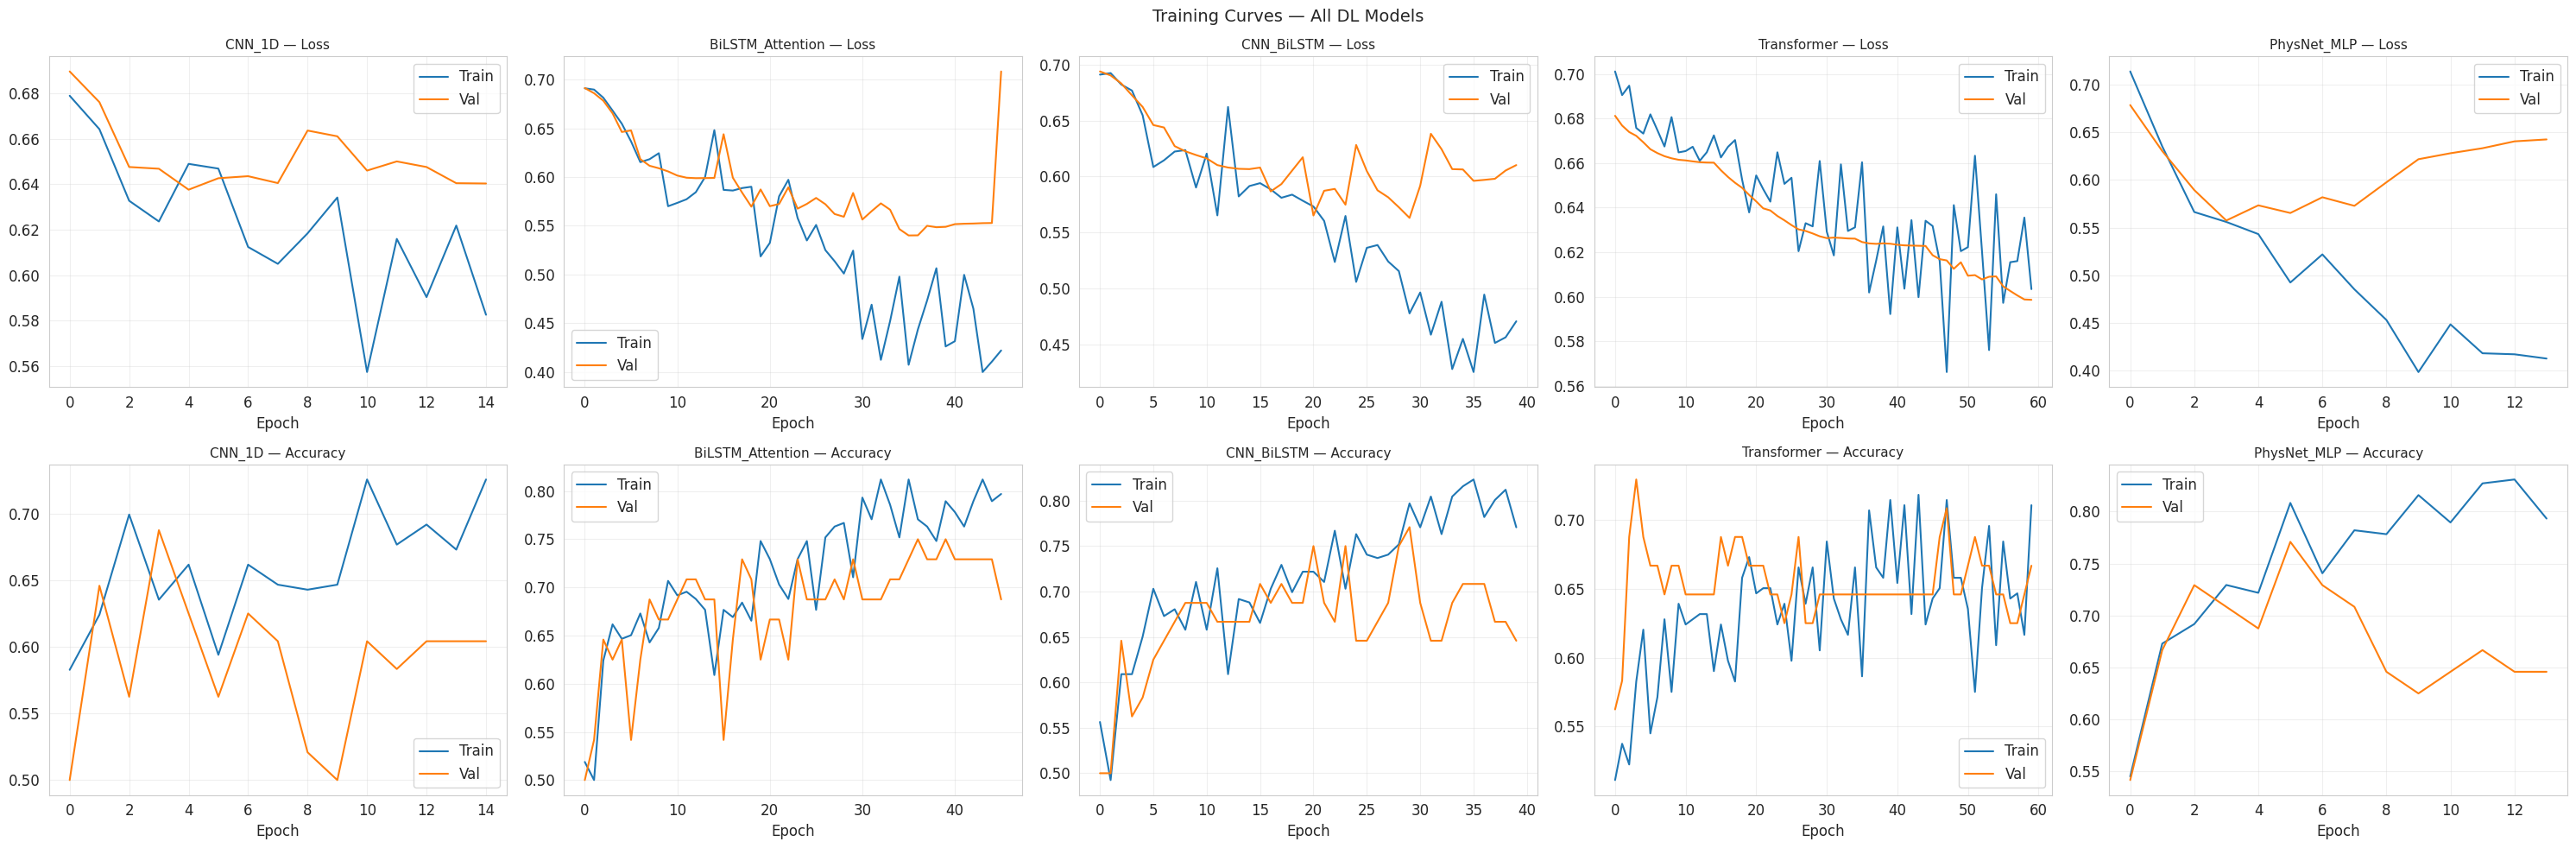

In [38]:
# ─── Training Curves ─────────────────────────────────────────────

fig, axes = plt.subplots(2, len(dl_histories), figsize=(6*len(dl_histories), 10))

for i, (name, hist) in enumerate(dl_histories.items()):
    # Loss
    axes[0, i].plot(hist['train_loss'], label='Train', linewidth=1.5)
    axes[0, i].plot(hist['val_loss'], label='Val', linewidth=1.5)
    axes[0, i].set_title(f'{name} — Loss', fontsize=11)
    axes[0, i].set_xlabel('Epoch')
    axes[0, i].legend()
    axes[0, i].grid(True, alpha=0.3)
    
    # Accuracy
    axes[1, i].plot(hist['train_acc'], label='Train', linewidth=1.5)
    axes[1, i].plot(hist['val_acc'], label='Val', linewidth=1.5)
    axes[1, i].set_title(f'{name} — Accuracy', fontsize=11)
    axes[1, i].set_xlabel('Epoch')
    axes[1, i].legend()
    axes[1, i].grid(True, alpha=0.3)

plt.suptitle('Training Curves — All DL Models', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'dl_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

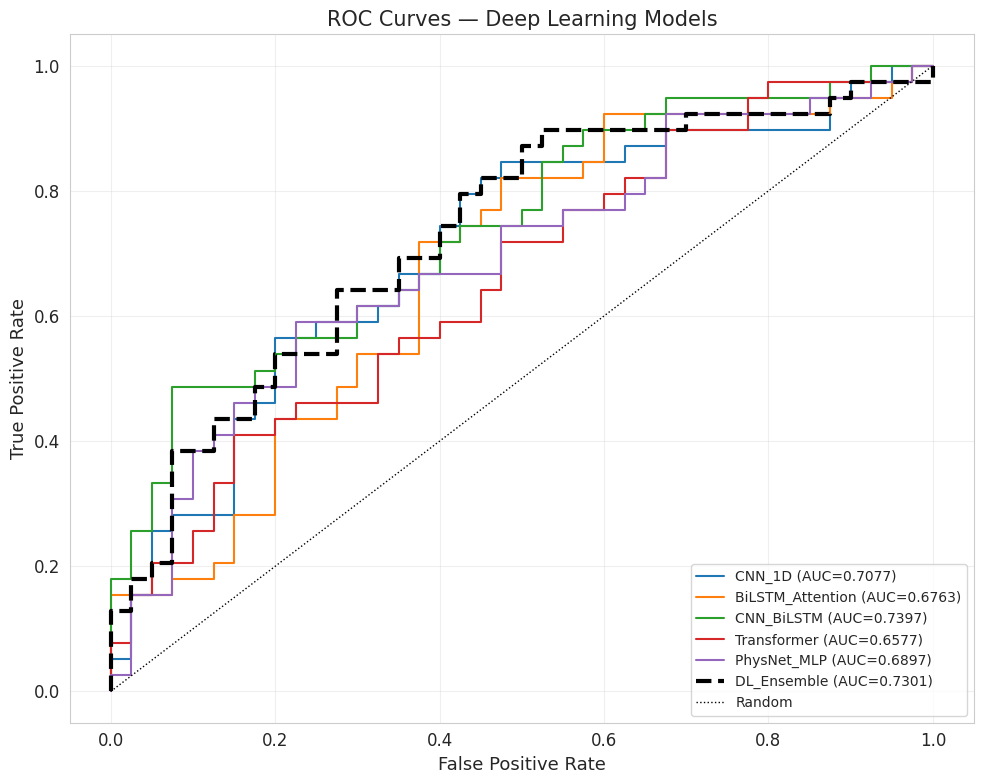

In [39]:
# ─── ROC Curves — All DL Models ──────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 8))

for name in dl_test_outputs:
    probs, labels = dl_test_outputs[name]
    fpr, tpr, _ = roc_curve(labels, probs)
    auc_val = roc_auc_score(labels, probs)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.4f})", linewidth=1.5)

# Ensemble
fpr_ens, tpr_ens, _ = roc_curve(test_labels_ens, ensemble_probs)
ax.plot(fpr_ens, tpr_ens, label=f"DL_Ensemble (AUC={ens_auc:.4f})",
        linewidth=3, linestyle='--', color='black')

ax.plot([0, 1], [0, 1], 'k:', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curves — Deep Learning Models', fontsize=15)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'dl_roc_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

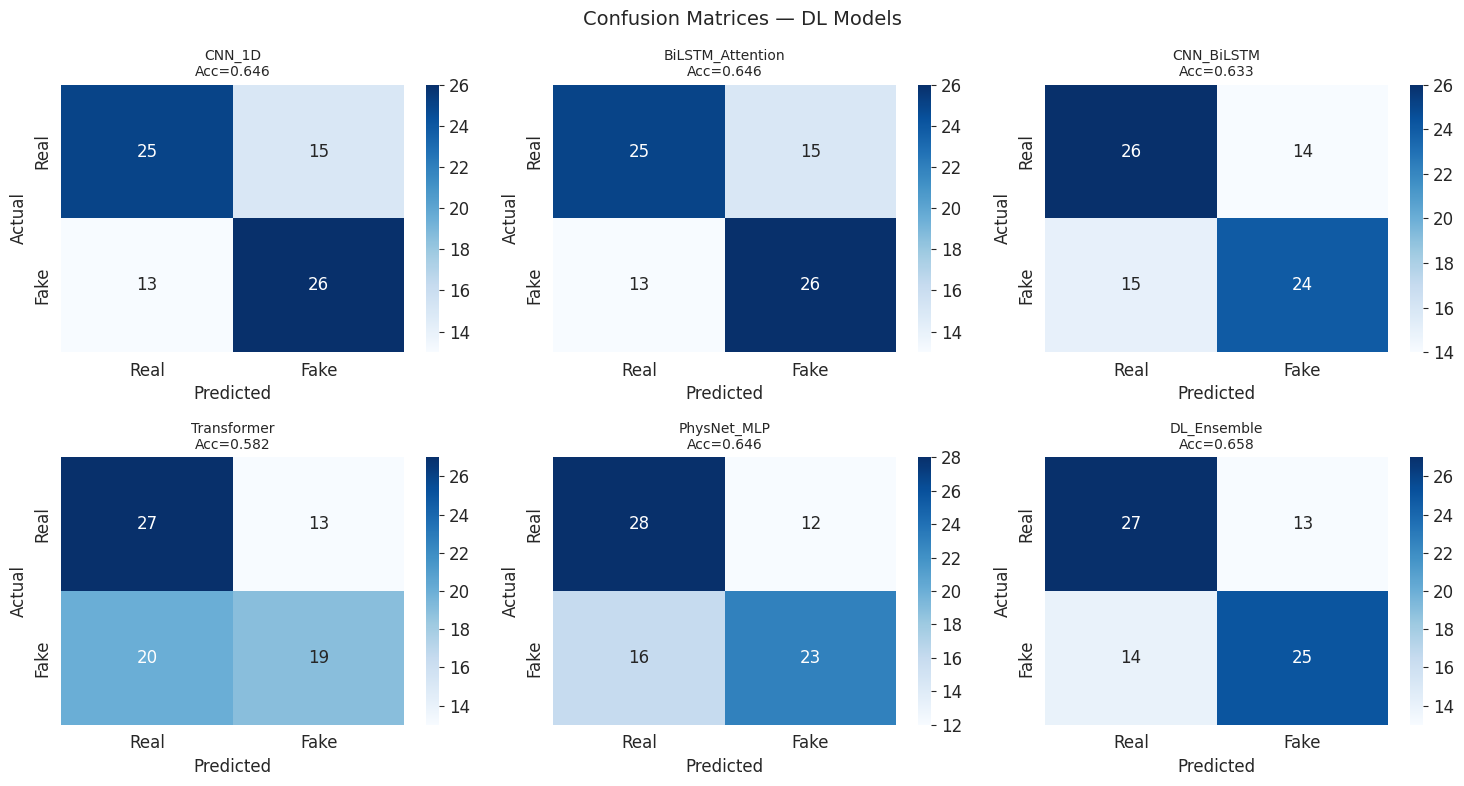

In [40]:
# ─── Confusion Matrices — All DL Models ──────────────────────────

model_names = list(dl_test_outputs.keys()) + ['DL_Ensemble']
n_models = len(model_names)
cols = 3
rows = (n_models + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
axes = axes.flatten()

for i, name in enumerate(model_names):
    if name == 'DL_Ensemble':
        probs = ensemble_probs
        labels = test_labels_ens
    else:
        probs, labels = dl_test_outputs[name]
    preds = (probs >= 0.5).astype(int)
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
    acc = accuracy_score(labels, preds)
    axes[i].set_title(f'{name}\nAcc={acc:.3f}', fontsize=10)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices — DL Models', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'dl_confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. Combined ML + DL Comparison

In [41]:
# ─── Load ML results and combine ────────────────────────────────

ml_results_path = os.path.join(OUTPUT_DIR, 'ml_results.csv')

if os.path.exists(ml_results_path):
    ml_df = pd.read_csv(ml_results_path, index_col=0)
    ml_df['type'] = 'ML'
    
    dl_df = dl_results_df[['accuracy', 'auc', 'f1', 'precision', 'recall']].copy()
    dl_df['type'] = 'DL'
    
    combined = pd.concat([ml_df[['accuracy', 'auc', 'f1', 'precision', 'recall', 'type']], dl_df])
    combined = combined.sort_values('auc', ascending=False)
    
    print("\n" + "="*80)
    print("COMBINED ML + DL COMPARISON — SORTED BY AUC")
    print("="*80)
    for col in ['accuracy', 'precision', 'recall', 'f1', 'auc']:
        combined[col] = combined[col].apply(lambda x: f"{x:.4f}" if isinstance(x, float) else str(x))
    print(combined.to_string())
    
    combined.to_csv(os.path.join(OUTPUT_DIR, 'combined_results.csv'))
    print(f"\nSaved to {OUTPUT_DIR}/combined_results.csv")
else:
    print("ML results not found. Run ML notebook first for combined comparison.")
    print("\nDL-only results:")
    print(display_df.to_string())


COMBINED ML + DL COMPARISON — SORTED BY AUC
                   accuracy     auc      f1 precision  recall type
LogisticRegression   0.6456  0.7423  0.5882    0.6897  0.5128   ML
CNN_BiLSTM           0.6329  0.7397  0.6234    0.6316  0.6154   DL
Ensemble_Top3        0.6709  0.7365  0.6061    0.7407  0.5128   ML
DL_Ensemble          0.6582  0.7301  0.6494    0.6579  0.6410   DL
LightGBM             0.6582  0.7192  0.5970    0.7143  0.5128   ML
XGBoost              0.6582  0.7115  0.5846    0.7308  0.4872   ML
GradientBoosting     0.6076  0.7090  0.5507    0.6333  0.4872   ML
ExtraTrees           0.6329  0.7077  0.5538    0.6923  0.4615   ML
CNN_1D               0.6456  0.7077  0.6500    0.6341  0.6667   DL
RandomForest         0.5949  0.6923  0.5152    0.6296  0.4359   ML
PhysNet_MLP          0.6456  0.6897  0.6216    0.6571  0.5897   DL
BiLSTM_Attention     0.6456  0.6763  0.6500    0.6341  0.6667   DL
Transformer          0.5823  0.6577  0.5352    0.5938  0.4872   DL
SVM_RBF          

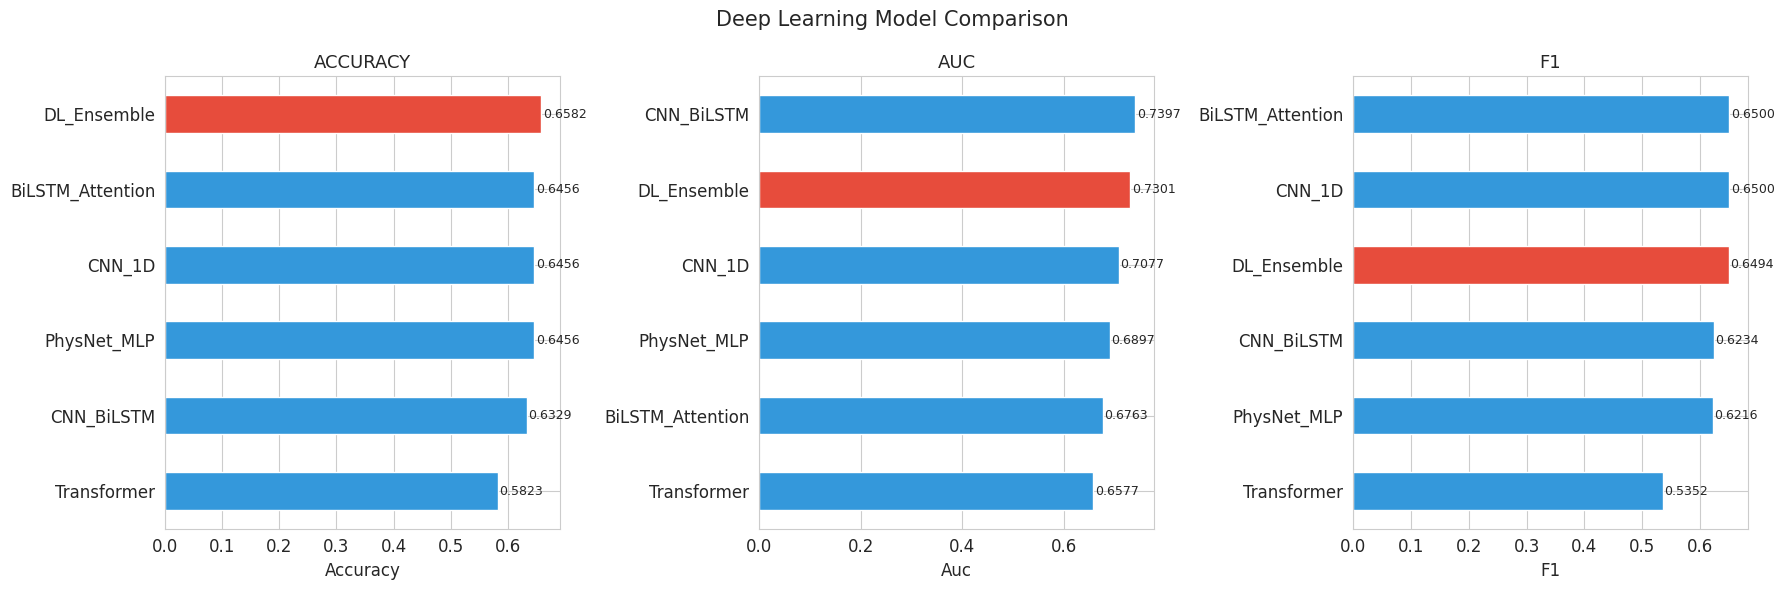

In [42]:
# ─── Bar chart comparison ────────────────────────────────────────

metrics_to_plot = ['accuracy', 'auc', 'f1']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Use float values
dl_plot_df = dl_results_df[['accuracy', 'auc', 'f1']].copy()
for col in dl_plot_df.columns:
    dl_plot_df[col] = pd.to_numeric(dl_plot_df[col], errors='coerce')

for i, metric in enumerate(metrics_to_plot):
    values = dl_plot_df[metric].sort_values(ascending=True)
    colors = ['#e74c3c' if 'Ensemble' in idx else '#3498db' for idx in values.index]
    values.plot(kind='barh', ax=axes[i], color=colors)
    axes[i].set_title(f'{metric.upper()}', fontsize=13)
    axes[i].set_xlabel(metric.capitalize())
    for j, v in enumerate(values):
        axes[i].text(v + 0.003, j, f'{v:.4f}', va='center', fontsize=9)

plt.suptitle('Deep Learning Model Comparison', fontsize=15)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'dl_comparison_bars.png'), dpi=150, bbox_inches='tight')
plt.show()

## 10. Best Model — Detailed Report

In [43]:
# ─── Best DL model detailed classification report ────────────────

best_name = dl_results_df.index[0]

if best_name == 'DL_Ensemble':
    best_probs = ensemble_probs
    best_labels = test_labels_ens
else:
    best_probs, best_labels = dl_test_outputs[best_name]

best_preds = (best_probs >= 0.5).astype(int)

print(f"{'='*60}")
print(f"BEST DL MODEL: {best_name}")
print(f"{'='*60}")
print(f"\nTest AUC: {roc_auc_score(best_labels, best_probs):.4f}")
print(f"\nClassification Report:")
print(classification_report(best_labels, best_preds, target_names=['Real', 'Deepfake']))

if best_name in dl_results and best_name != 'DL_Ensemble':
    print(f"\nModel config:")
    cfg = dl_models[best_name]
    print(f"  lr: {cfg['lr']}")
    print(f"  weight_decay: {cfg['weight_decay']}")
    print(f"  epochs_trained: {dl_results[best_name]['epochs_trained']}")

BEST DL MODEL: CNN_BiLSTM

Test AUC: 0.7397

Classification Report:
              precision    recall  f1-score   support

        Real       0.63      0.65      0.64        40
    Deepfake       0.63      0.62      0.62        39

    accuracy                           0.63        79
   macro avg       0.63      0.63      0.63        79
weighted avg       0.63      0.63      0.63        79


Model config:
  lr: 0.0005
  weight_decay: 0.0001
  epochs_trained: 40


## 11. Save All Artifacts

In [44]:
# ─── Final save ──────────────────────────────────────────────────

# Save scaler
import joblib
joblib.dump(scaler, os.path.join(OUTPUT_DIR, 'dl_scaler.joblib'))

# Summary
print("\nSaved artifacts:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, f)
    if os.path.isfile(fpath):
        size_mb = os.path.getsize(fpath) / 1024 / 1024
        print(f"  {f}: {size_mb:.2f} MB")

print(f"\n{'='*60}")
print("TRAINING COMPLETE")
print(f"{'='*60}")
print(f"ML models:  7 + 1 ensemble (see 01_ml_training.ipynb)")
print(f"DL models:  5 + 1 ensemble")
print(f"Total:      14 models evaluated")
print(f"\nBest DL model: {best_name} (AUC={dl_results[best_name]['auc']:.4f})")
print(f"\nAll models and results saved to: {OUTPUT_DIR}/")


Saved artifacts:
  BiLSTM_Attention_checkpoint.pth: 0.68 MB
  CNN_1D_checkpoint.pth: 0.16 MB
  CNN_BiLSTM_checkpoint.pth: 0.70 MB
  Ensemble_Top3_best.joblib: 1.62 MB
  ExtraTrees_best.joblib: 4.66 MB
  GradientBoosting_best.joblib: 0.85 MB
  LightGBM_best.joblib: 0.39 MB
  LogisticRegression_best.joblib: 0.00 MB
  PhysNet_MLP_checkpoint.pth: 0.46 MB
  RandomForest_best.joblib: 1.79 MB
  SVM_RBF_best.joblib: 0.07 MB
  Transformer_checkpoint.pth: 0.12 MB
  XGBoost_best.joblib: 0.42 MB
  X_test.npy: 0.02 MB
  X_test_scaled.npy: 0.02 MB
  X_train.npy: 0.08 MB
  X_train_scaled.npy: 0.08 MB
  combined_results.csv: 0.00 MB
  confusion_matrices.png: 0.15 MB
  correlation_matrix.png: 0.24 MB
  dl_comparison_bars.png: 0.10 MB
  dl_confusion_matrices.png: 0.11 MB
  dl_results.csv: 0.00 MB
  dl_roc_curves.png: 0.11 MB
  dl_scaler.joblib: 0.00 MB
  dl_training_curves.png: 0.65 MB
  feature_distributions.png: 0.49 MB
  feature_importance.png: 0.28 MB
  features.csv: 0.23 MB
  features.npy: 0.11 MB

In [45]:
import shutil

shutil.make_archive("m_outputs", 'zip', "/kaggle/working")

'/kaggle/working/m_outputs.zip'